In [1]:
import os
from dotenv import load_dotenv
import json
import csv
import re
import math
from datetime import datetime
from docx import Document
from random import choice
from string import Template
from typing import Union
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import tiktoken
from openai import OpenAI
from pydantic import BaseModel, Field, ValidationError
from sklearn.metrics import accuracy_score, mean_absolute_error, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import spearmanr, pearsonr
import pingouin as pg

# Data Imports

In [2]:
#Create a Path object for current working directory
cwd = Path.cwd()
print(cwd)

c:\Users\hfk66\OneDrive - University of Keele\Current Research\Automatic SAQ Marking\Fine-tuning project\v3


In [4]:
# Define required directories within cwd
required_dirs = ["data", "jsonl_files", "model_outputs", "evaluation"]

# Create them if they do not exist
for folder in required_dirs:
    (cwd / folder).mkdir(exist_ok=True)

In [3]:
''' 
main_data_df initial contains all 19 questions. Image questions are subsequently dropped from this df
It does NOT contain the questions which were removed manually for few-shot examples.
Few shot examples are loaded separately in few_shot_questions_df 
'''
main_data_path = cwd / "data" / "yr1_may2022_main_data.csv" 
main_data_df = pd.read_csv(main_data_path)
#main_data_df

In [4]:
few_shot_questions_path = cwd / "data" / "few_shot_questions.csv"
few_shot_df = pd.read_csv(few_shot_questions_path)
#few_shot_df

In [5]:
# load df containing details of each question
question_parameters_path = cwd / "data" / "yr1_may2022_question_parameters.csv"
question_parameters_df =pd.read_csv(question_parameters_path)
#question_parameters_df

In [10]:
# drop or include questions which contain images:
include_image_questions = False
if not include_image_questions:
    image_questions = question_parameters_df.loc[
        question_parameters_df['image_bool'] == True, 'question_id'
    ].unique().tolist()

print(f"Excluding the following questions as they contiain images: {image_questions}")

# retain only the rows without image questions
main_data_df = main_data_df[~main_data_df['question_id'].isin(image_questions)]
remaining_quesions = main_data_df['question_id'].unique().tolist()
print(f"Remaining questions: {remaining_quesions}")

Excluding the following questions as they contiain images: [2, 14]
Remaining questions: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19]


Identify and mark complete data (i.e. students where none of their responses were removed for few shot examples) 

In [11]:
main_data_df['complete'] = (
    main_data_df.groupby('student_id')['question_id']
    .transform('count') == len(remaining_quesions)
)
complete_data_df = main_data_df[main_data_df['complete'] == True]
incomplete_data_df = main_data_df[main_data_df['complete'] == False]


In [12]:
incomplete_students = incomplete_data_df['student_id'].unique().tolist()
complete_students = complete_data_df['student_id'].unique().tolist()
print(f"Incomplete students: {incomplete_students}")
print(f"Number of incomplete students: {len(incomplete_students)}")
print(f"Complete students: {complete_students}")
print(f"Number of Complete students: {len(complete_students)}")

duplicates = []
for n in complete_students:
    if n in incomplete_students:
        duplicates.append(n)
print(f"duplicates: {duplicates}")

Incomplete students: [1036103, 1123688, 1858906, 2641515, 2846399, 5581657, 5859454, 1145751, 1192656, 2127134, 2143585, 2948333, 3195851, 4556020, 5169481, 6971827, 7907224, 8542901, 9157659, 1206142, 1660732, 2102866, 2772453, 3601559, 4497465, 5676142, 6744278, 7092520, 8835787, 1123260, 1659767, 2001219, 2271290, 2766323, 2796903, 6428233, 8927817, 1357709, 1496071, 3308349, 3948683, 4642671, 7239536, 8038298, 8293259, 8402801, 1948081, 2562517, 3884317, 4833784, 7560721, 1556300, 3222916, 5228947, 5343678, 1283214, 1682894, 1891593, 5396088, 7429482, 9001174, 1022133, 9383909, 2038468, 8372081, 5244105]
Number of incomplete students: 66
Complete students: [1063917, 1154492, 1435920, 1728814, 4186716, 4345662, 4448598, 4546254, 4663479, 4728201, 5043648, 5297978, 5307351, 5755536, 5798411, 6229336, 6375549, 6719753, 6895217, 7329479, 7462337, 8344896, 8482806, 8546248, 8584036, 8692013, 9722712, 1154398, 1276325, 3584976, 4003596, 6288701, 6333608, 6669988, 7468903, 7475474, 788545

In [13]:
# calculate proportion of complete data required to produce desired proportion of overall testing data
n_complete = len(complete_data_df)
print(f"n_complete: {n_complete}")
n_main_data = len(main_data_df)
print(f"n_main_data: {n_main_data}")
overall_test_proportion = 0.33

complete_test_proportion = (overall_test_proportion * n_main_data) / n_complete 
print(f"Proportion of complete data to be held back for testing: {complete_test_proportion:.2f}")



n_complete: 1938
n_main_data: 2975
Proportion of complete data to be held back for testing: 0.51


# Data Splitting

In [11]:
# Calculate total score per student
student_total_scores = (
    complete_data_df
    .groupby('student_id')['marker_score']
    .sum()
    .reset_index()
)

# Create quantile-based score bins to prevent stratification problems due to low numbers
student_total_scores['score_bin'] = pd.qcut(
    student_total_scores['marker_score'], 
    q=10,  # number of bins
    duplicates='drop'  # avoids errors if bins have no range
)

# Split students_id, stratified by score bin
residual_students, testing_students = train_test_split(
    student_total_scores,
    test_size=complete_test_proportion,
    random_state=42,
    stratify=student_total_scores['score_bin']
)

# use split student_ids to select from complete_data_df:
testing_data_df = complete_data_df[complete_data_df['student_id'].isin(testing_students['student_id'])]
complete_residual_df = complete_data_df[complete_data_df['student_id'].isin(residual_students['student_id'])]

# print(f"testing data df: {testing_data_df}")
# print(f"complete_residual_df: {complete_residual_df}")

In [ ]:
testing_data_df

In [14]:
print(f"Unique students in testing data:{testing_data_df['student_id'].nunique()}")
print(f"Unique students in residual complete data:{complete_residual_df['student_id'].nunique()}")

Unique students in testing data:58
Unique students in residual complete data:56


In [15]:
print(f"frequency of null responses in each category:\n{testing_data_df.isnull().sum()}")

frequency of null responses in each category:
question_id         0
student_id          0
student_response    1
marker_score        0
marker_feedback     2
complete            0
dtype: int64


In [16]:
complete_residual_df

,question_id,student_id,student_response,marker_score,marker_feedback,complete
1,1,1063917,Leydig cells secrete luteinising hormone. \nMe...,0.0,Answer is very confused. Review ovulation,True
4,1,1435920,LH is released from the pituitary gland and du...,0.0,"Answer is very vague, more detail needed to an...",True
5,1,1728814,"During the follicular phase, oestrogen is at l...",0.0,Answer is confused. Review ovulation. Make sur...,True
9,1,4186716,- During the menstrual cycle LH hormone levels...,0.0,Answer is very superifical and mostly irreleva...,True
20,1,5798411,LH is a useful marker for ovulation as the hor...,0.0,"Answer is very vague, more detail needed to an...",True
...,...,...,...,...,...,...
3299,19,9326849,Venoconstriction leads to an increased preload...,1.0,"You have the right idea, but more detail neede...",True
3316,19,1453120,A lot of blood is contained within the venous ...,2.0,Excellent answer. Well done!,True
3319,19,5163828,Increase in venoconstriction will cause increa...,2.0,Good answer,True
3320,19,7198306,Constriction of the veins leads to increased c...,2.0,Good answer. Well done!,True


In [17]:
print(f"frequency of null responses in each category:\n{complete_residual_df.isnull().sum()}")

frequency of null responses in each category:
question_id         0
student_id          0
student_response    3
marker_score        0
marker_feedback     0
complete            0
dtype: int64


In [18]:
# Create training/vlaidation data by concatenating residual complete and incomplete data
train_val_df = pd.concat([complete_residual_df, incomplete_data_df], ignore_index= True)

In [19]:
train_val_df

,question_id,student_id,student_response,marker_score,marker_feedback,complete
0,1,1063917,Leydig cells secrete luteinising hormone. \nMe...,0.0,Answer is very confused. Review ovulation,True
1,1,1435920,LH is released from the pituitary gland and du...,0.0,"Answer is very vague, more detail needed to an...",True
2,1,1728814,"During the follicular phase, oestrogen is at l...",0.0,Answer is confused. Review ovulation. Make sur...,True
3,1,4186716,- During the menstrual cycle LH hormone levels...,0.0,Answer is very superifical and mostly irreleva...,True
4,1,5798411,LH is a useful marker for ovulation as the hor...,0.0,"Answer is very vague, more detail needed to an...",True
...,...,...,...,...,...,...
1984,19,8293259,An increase in constriction of the veins in An...,1.5,"Good answer, which could be improved with refe...",False
1985,19,8402801,Constriction of vein would mean a greater cent...,1.5,"You have the right idea, but some detail missing",False
1986,19,1891593,Venoconstriction results in increased pressure...,2.0,"GOod answer, well done",False
1987,19,7560721,stroke volume is the volume of blood ejected f...,2.0,Some superfluous information is included at th...,False


In [ ]:
print(f"Unique students in train_val data: {train_val_df['student_id'].nunique()}")

Unique students in ttrain_val data: 122


In [21]:
print(f"frequency of null responses in each category:\n{train_val_df.isnull().sum()}")

frequency of null responses in each category:
question_id          0
student_id           0
student_response    11
marker_score         0
marker_feedback      4
complete             0
dtype: int64


Removing questions from training & validation data to test generalization

In [22]:
n_reserve = 3
add_back = False
testing_questions = list(testing_data_df['question_id'].unique())
removed_questions_df = pd.DataFrame()
for i in range(n_reserve):
    q = choice(testing_questions)
    testing_questions.remove(q)
    removed = train_val_df[train_val_df['question_id'] == q]
    train_val_df = train_val_df[train_val_df['question_id'] !=q]
    removed_questions_df = pd.concat([removed_questions_df, removed], ignore_index=True)

#optionally, add the removed questions into the testing set
if add_back is True:
    testing_data_df = pd.concat([testing_data_df, removed_questions_df], ignore_index=True)


In [23]:
print(f"Unique questions in train_val data: {train_val_df['question_id'].nunique()}")

Unique questions in train_val data: 14


In [ ]:
removed_questions_df

Second split to create validation and training datasets

In [25]:
# Calculate total score per student
student_total_scores = (
    train_val_df
    .groupby('student_id')['marker_score']
    .sum()
    .reset_index()
)

# Create quantile-based score bins to prevent strification problems due to low numbers
student_total_scores['score_bin'] = pd.qcut(
    student_total_scores['marker_score'], 
    q=10,  # number of bins
    duplicates='drop'  # avoids errors if bins have no range
)

# Split students_id, stratified by score bin
training_students, validation_students = train_test_split(
    student_total_scores,
    test_size=0.2,
    random_state=42,
    stratify=student_total_scores['score_bin']
)

# use split student_ids to select from train_val_df:
validation_data_df = train_val_df[train_val_df['student_id'].isin(validation_students['student_id'])]
training_data_df = train_val_df[train_val_df['student_id'].isin(training_students['student_id'])]

# print(f"training data df: {training_data_df}")
# print(f"validation data df: {validation_data_df}")

In [27]:
#Check frequencies of complete and incomplete data in each data set:

#Testing set:
student_question_counts = testing_data_df.groupby('student_id')['question_id'].count()

question_completion_frequencies = student_question_counts.value_counts().sort_index()

print("Testing data:")
for questions_answered, student_count in question_completion_frequencies.items():
    print(f"{questions_answered} questions answered: {student_count} students")

#Training Validation data set:
student_question_counts = train_val_df.groupby('student_id')['question_id'].count()

question_completion_frequencies = student_question_counts.value_counts().sort_index()

print("Training Validation data:")
for questions_answered, student_count in question_completion_frequencies.items():
    print(f"{questions_answered} questions answered: {student_count} students")

Testing data:
17 questions answered: 58 students
Training Validation data:
10 questions answered: 1 students
11 questions answered: 1 students
12 questions answered: 11 students
13 questions answered: 42 students
14 questions answered: 67 students


In [28]:
train_val_df

,question_id,student_id,student_response,marker_score,marker_feedback,complete
0,1,1063917,Leydig cells secrete luteinising hormone. \nMe...,0.0,Answer is very confused. Review ovulation,True
1,1,1435920,LH is released from the pituitary gland and du...,0.0,"Answer is very vague, more detail needed to an...",True
2,1,1728814,"During the follicular phase, oestrogen is at l...",0.0,Answer is confused. Review ovulation. Make sur...,True
3,1,4186716,- During the menstrual cycle LH hormone levels...,0.0,Answer is very superifical and mostly irreleva...,True
4,1,5798411,LH is a useful marker for ovulation as the hor...,0.0,"Answer is very vague, more detail needed to an...",True
...,...,...,...,...,...,...
1984,19,8293259,An increase in constriction of the veins in An...,1.5,"Good answer, which could be improved with refe...",False
1985,19,8402801,Constriction of vein would mean a greater cent...,1.5,"You have the right idea, but some detail missing",False
1986,19,1891593,Venoconstriction results in increased pressure...,2.0,"GOod answer, well done",False
1987,19,7560721,stroke volume is the volume of blood ejected f...,2.0,Some superfluous information is included at th...,False


# Visualise score distributions by question and by dataset

In [30]:
# Count of each score per question in training/validation
train_score_counts = (
    training_data_df
    .groupby(['question_id', 'marker_score'])
    .size()
    .reset_index(name='count')
    .assign(source='train')
)

val_score_counts = (
    validation_data_df
    .groupby(['question_id', 'marker_score'])
    .size()
    .reset_index(name='count')
    .assign(source='validation')

)
# Count of each score per question in testing
test_score_counts = (
    testing_data_df
    .groupby(['question_id', 'marker_score'])
    .size()
    .reset_index(name='count')
    .assign(source='test')
)

# Combine the two
score_comparison_df = pd.concat([train_score_counts, val_score_counts, test_score_counts], ignore_index=True)


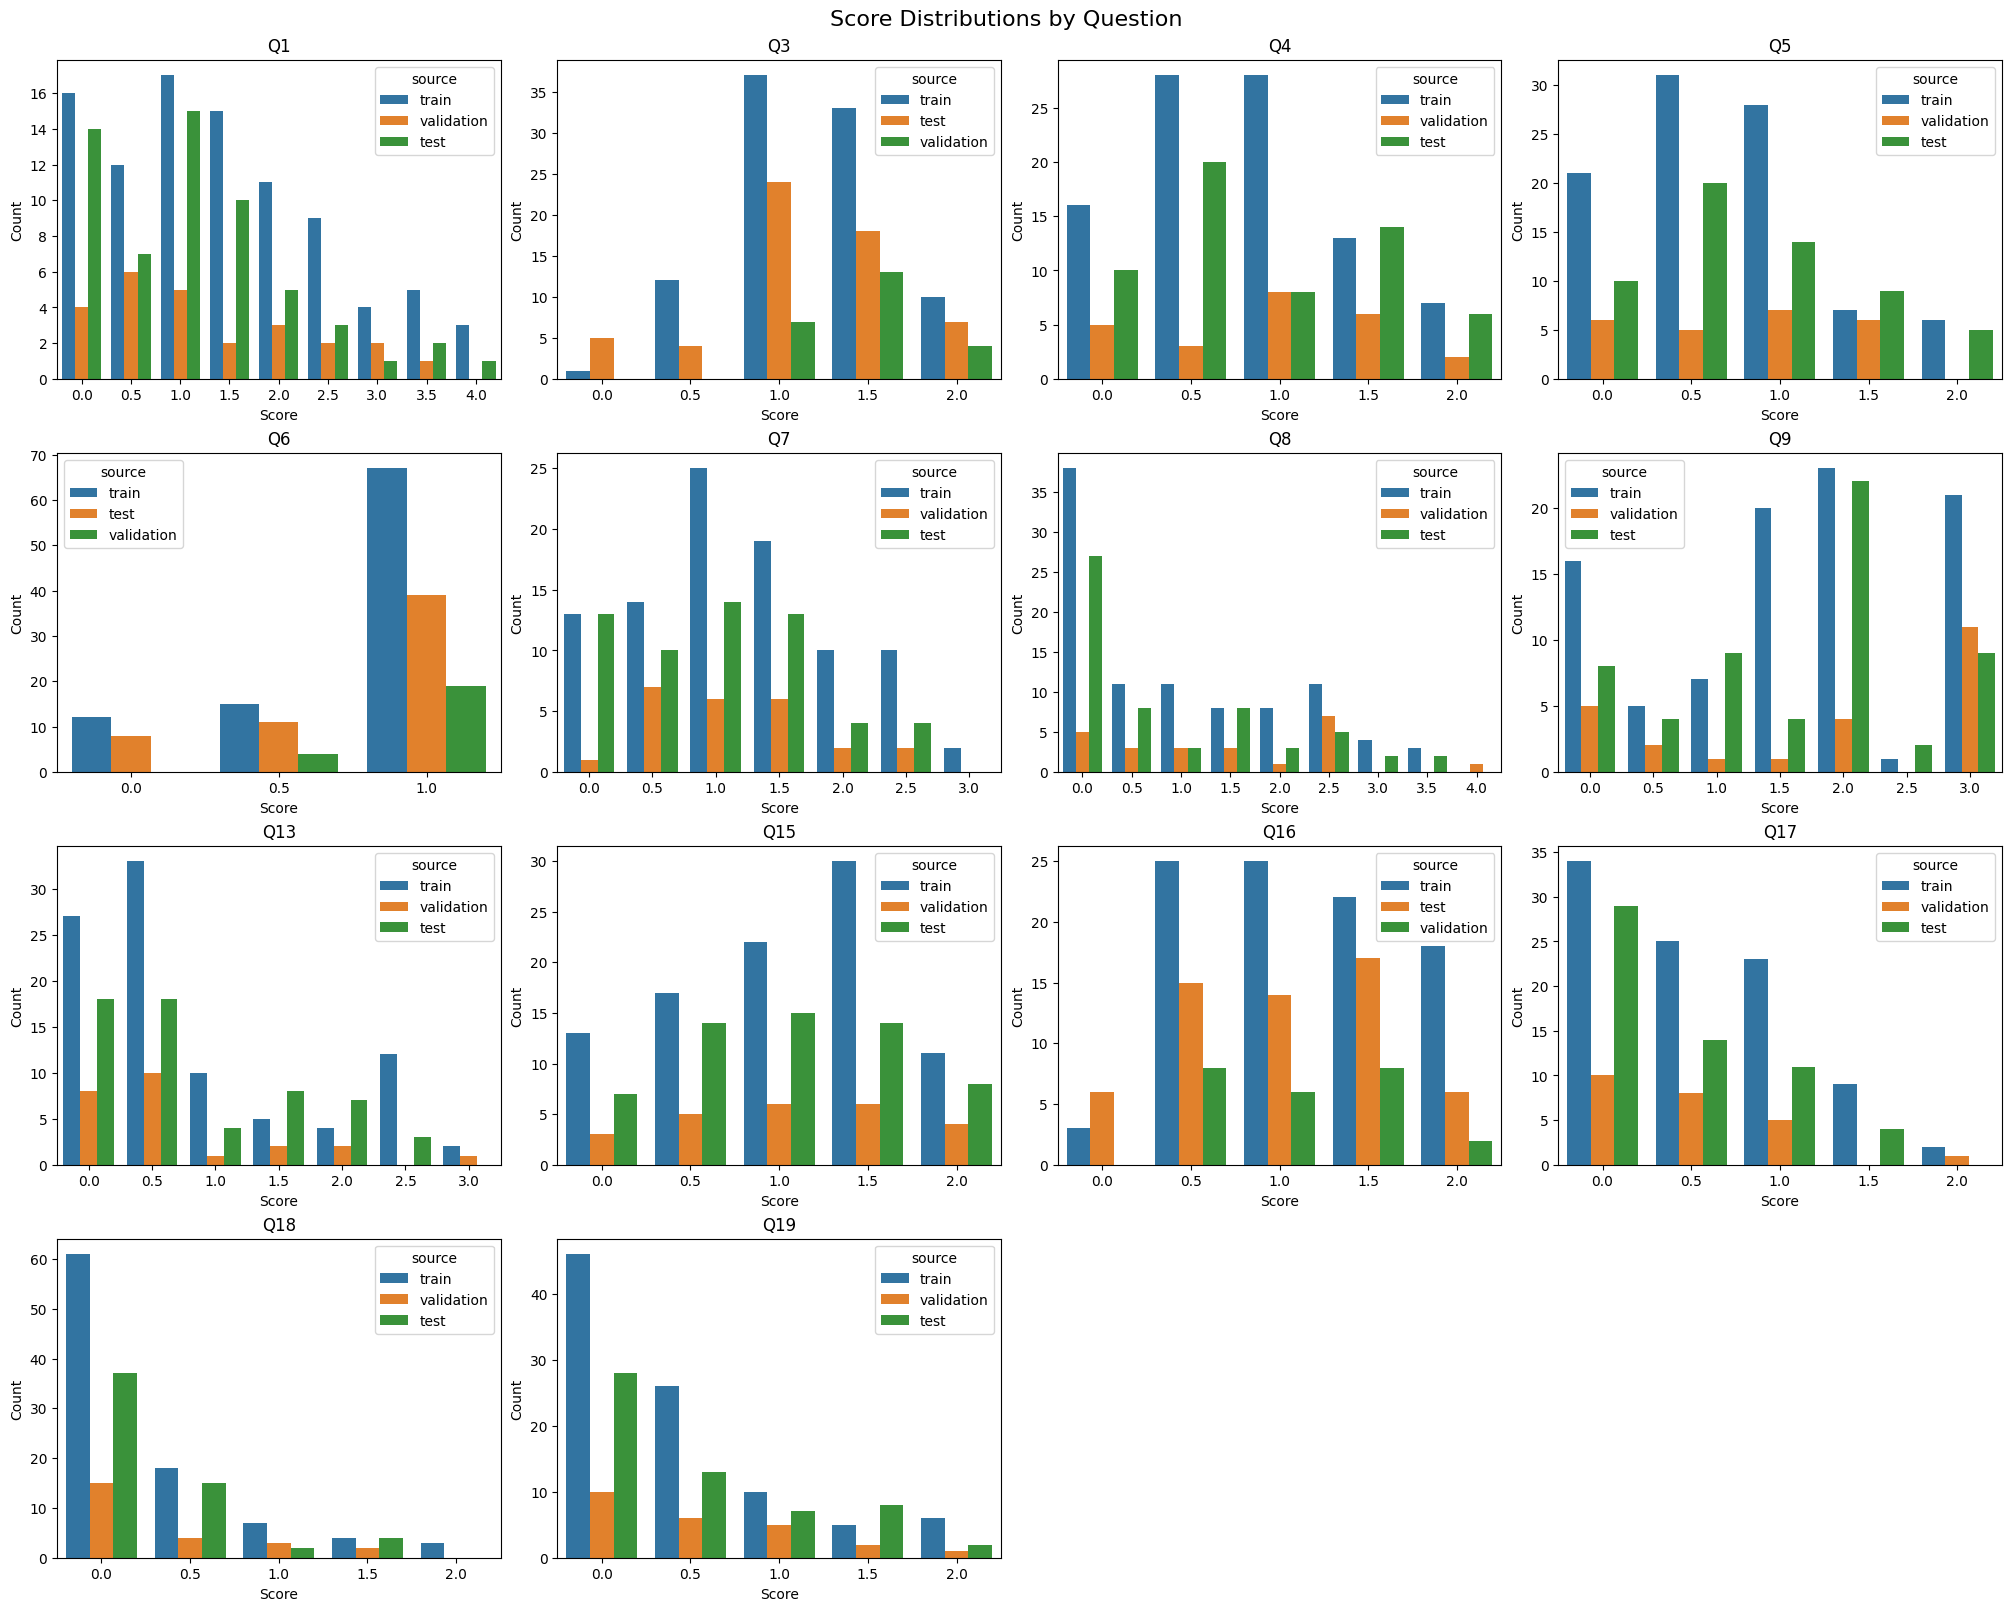

In [31]:
# Get list of available questions
question_ids = training_data_df['question_id'].unique()
n_questions = len(question_ids)

# Determine number of subplot rows and columns
n_cols = 4  # Adjust this for layout
n_rows = (n_questions + n_cols - 1) // n_cols  # Ceiling division

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), constrained_layout=True)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Plot each question
for i, q in enumerate(question_ids):
    ax = axes[i]
    plot_df = score_comparison_df[score_comparison_df['question_id'] == q]
    
    if not plot_df.empty:
        sns.barplot(
            data=plot_df,
            x='marker_score', 
            y='count', 
            hue='source',
            ax=ax
        )
        ax.set_title(f"Q{q}")
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
    else:
        ax.set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Score Distributions by Question", fontsize=16)
plt.show()


In [ ]:
# Persist the datasets as .csv files in the data folder

testing_data_path = cwd / "data" / 'testing_data.csv'
testing_data_df.to_csv(testing_data_path, index=False)

training_data_path = cwd / "data" / 'training_data.csv'
training_data_df.to_csv(training_data_path, index=False)

validation_data_path = cwd / "data" / 'validation_data.csv'
validation_data_df.to_csv(validation_data_path, index=False)

In [8]:
# Re-load datasets if restarting session 
testing_data_path = cwd / "data" / 'testing_data.csv'
testing_data_df = pd.read_csv(testing_data_path)

training_data_path = cwd / "data" / 'training_data.csv'
training_data_df = pd.read_csv(training_data_path)

validation_data_path = cwd / "data" / 'validation_data.csv'
validation_data_df = pd.read_csv(validation_data_path)

few_shot_df = pd.read_csv(few_shot_questions_path)

# Prompt Preparation

Define function to create jsonl files

In [16]:
def create_openai_jsonl(
    prompt_file_name: str,
    data_frame: pd.DataFrame,
    question_parameters_df: pd.DataFrame,
    few_shot: bool = False,
    few_shot_instruction_file: str = None,
    few_shot_df: pd.DataFrame = None,
    assistant_scores: bool = False,
    assistant_feedback: bool = False
) -> list:
    
    """ 
    This function takes in:
    1. a general prompt file
    2. a dataframe of either testing, training, or validation data
    3. the question parameters df
    Optionally (if few shot is desired):
    4. a few_shot instructions prompt file
    5. a df of few shot examples if formating for few shot prompting
    Optionally:
    If "assistant_scores" is True, it will add the human score for each student response in an assistant message.
    If "assistant_feedback is True, it will add the human feedback for each student response in an assistant message.
    One or both of these should therefore be selected for training or validation datasets.

    Returns:
        JSONL file (a list of json objects)
        Each json will comprise: 
            prompt text -> question id -> question text and marking guidance 
            -> [+/- few shot instructions prompt and few shot examples ] - if selected in function call
            -> student id -> student response to question 
            -> [+/- human marker score and/or human marker feedback] - if selected in function call
    """
    #Load system prompt text
    doc = Document(prompt_file_name)
    system_prompt = "\n".join([p.text for p in doc.paragraphs if p.text.strip()])

    # Add optional few-shot instruction text
    fs_text = None
    if few_shot and few_shot_instruction_file:
        fs_doc = Document(few_shot_instruction_file)
        fs_text = "\n".join([p.text for p in fs_doc.paragraphs if p.text.strip()])

    jsonl_data = []  

    for _, row in data_frame.iterrows():
        student_id = str(row["student_id"])  
        question_id = str(row["question_id"])  
        student_response = row["student_response"]
        marker_score = row["marker_score"]
        marker_feedback = row["marker_feedback"]

        qrow = question_parameters_df.loc[question_parameters_df["question_id"].astype(str) == question_id]
        if qrow.empty:
            print(f"Warning: question_id {question_id} not found; skipping")  
            continue

        question_text = qrow["question"].iloc[0]
        marking_guidance = qrow["marking_guidance"].iloc[0]
        max_score = qrow["max_score"].iloc[0] if "max_score" in qrow.columns else None  

        #Assemble user message content
        parts = [
            f"question_id: {question_id}",
            f"question: {question_text}",
            f"marking_guidance: {marking_guidance}",
            f"maximum_available_marks: {max_score}" if max_score is not None else None,
        ]

        #Few-shot examples appended into user content if Few_Shot is True and there is a few_shot_df
        if few_shot and fs_text and few_shot_df is not None:
            examples = []
            for _, ex in few_shot_df[few_shot_df["question_id"].astype(str) == question_id].iterrows():
                examples.append(
                    f"Example student response: {ex['student_response']}\n"
                    f"Score awarded by marker: {ex['marker_score']}\n"
                    f"Feedback from marker: {ex['marker_feedback']}"
                )
            if examples:
                parts.append(fs_text + "\n\nFew-shot calibration examples:\n" + "\n\n".join(examples))

        parts.append(f"student_id: {student_id}")
        parts.append("student_response for you to score: " + str(student_response))
        user_content = "\n".join([p for p in parts if p])

              
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
            ]

        #Add assistant message containing human score and human feedback for each specific student response if this option is selected in function call  
        if assistant_scores or assistant_feedback:
            assistant_payload = {
                "student_id": student_id,
                "question_id": question_id,
            }
            if assistant_scores:
                assistant_payload["marker_score"] = marker_score
            if assistant_feedback:
                assistant_payload["marker_feedback"] = marker_feedback,

            messages.append({"role": "assistant", 
                                "content": json.dumps(assistant_payload, ensure_ascii=False)})
                                                        
        jsonl_data.append({"messages" : messages})
            

    return jsonl_data  

# Example use of this function (adjust data_frame to training/validation/testing as needed)
# data = create_openai_jsonl(
#     "general_prompt.docx",
#     training_data_df,
#     question_parameters_df,
#     few_shot=True,
#     few_shot_instruction_file="few_shot_instructions.docx",
#     few_shot_df=few_shot_df,
# )
# Then save data:
# training_data_ft_path = cwd / "jsonl_files" / "training_data_fine_tune.jsonl"
# with open(training_data_ft_path, "w", encoding="utf-8") as f:
#     for item in data:
#         f.write(json.dumps(item, ensure_ascii=False) + "\n")


Calls to create required JSONL datasets

In [14]:
# testing zero shot
data_test_zs = create_openai_jsonl(
    "general_prompt.docx",
    testing_data_df,
    question_parameters_df,
    few_shot=False
)

testing_zs_path = cwd / "jsonl_files" / "testing_zero_shot.jsonl"
with open(testing_zs_path, "w", encoding="utf-8") as f:
    for item in data_test_zs:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

# testing few shot
data_test_fs = create_openai_jsonl(
    "general_prompt.docx",
    testing_data_df,
    question_parameters_df,
    few_shot=True,
    few_shot_instruction_file="few_shot_instructions.docx",
    few_shot_df=few_shot_df,
)

testing_fs_path = cwd / "jsonl_files" / "testing_few_shot.jsonl"
with open(testing_fs_path, "w", encoding="utf-8") as f:
    for item in data_test_fs:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")



# training data for supervised fine tuning (true scores ONLY supplied via assistant message)
data_train = create_openai_jsonl(
    "general_prompt.docx",
    training_data_df,
    question_parameters_df,
    few_shot=False,
    assistant_scores=True
)

training_data_ft_path = cwd / "jsonl_files" / "training_data_fine_tune_scores_only.jsonl"
with open(training_data_ft_path, "w", encoding="utf-8") as f:
    for item in data_train:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")


# validation data for supervised fine tuning (true scores ONLY supplied via assistant message)
data_val = create_openai_jsonl(
    "general_prompt.docx",
    validation_data_df,
    question_parameters_df,
    few_shot=False,
    assistant_scores=True
)

validation_data_ft_path = cwd / "jsonl_files" / "validation_data_fine_tune_scores_only.jsonl"
with open(validation_data_ft_path, "w", encoding="utf-8") as f:
    for item in data_val:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

In [20]:
# Visualize rows from the created jsonl to verify
# Substitute file name and range as needed
with open(validation_data_ft_path, "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().rstrip())

{"messages": [{"role": "system", "content": "You are an expert medical doctor and a skilled medical educator. Your task is to score free text written examination questions which have been completed by undergraduate medical students. Scoring accurately is extremely important. Please score fairly according to the marking guidance provided. Please consider the reasoning in the response rather than just the presence or absence of appropriate words. The score must be a single numeric value between 0 and maximum_available_marks (inclusive). Half marks may be used if the marking guidance indicates that half marks are available. Scoring accuracy is more important than encouragement. Please provide constructive feedback on the student’s performance. Keep feedback concise and focused on the most important strengths and omissions. Feedback should reflect the awarded score. Feedback should not exceed 300 tokens. Return a JSON object with the following fields: student_id, question_id, marker_score,

In [13]:
question_parameters_df.columns

Index(['question_id', 'question', 'marking_guidance', 'max_score', 'unit',
       'tag', 'free_text_descriptor', 'image_bool', 'Bloom', 'Why'],
      dtype='str')

In [14]:
human_descriptives_df.columns

Index(['question_id', 'student_id', 'student_response', 'marker_score',
       'marker_feedback', 'complete'],
      dtype='str')

In [6]:
included_max_total_score = question_parameters_df[question_parameters_df["image_bool"] == False]["max_score"].sum()
included_max_total_score

np.int64(43)

In [21]:
human_descriptives_df = testing_data_df.copy()
#included_max_total_score = question_parameters_df[question_parameters_df["image_bool"] == False]["max_score"].sum()
max_scores = question_parameters_df[['question_id', "max_score"]]
max_scores

,question_id,max_score
0,1,4
1,2,3
2,3,2
3,4,2
4,5,2
5,6,1
6,7,3
7,8,4
8,9,3
9,10,2


Proportions:percent_total
0.000000    0.315416
0.125000    0.021298
0.166667    0.036511
0.250000    0.160243
0.333333    0.028398
0.375000    0.030426
0.500000    0.159229
0.625000    0.015213
0.666667    0.033469
0.750000    0.098377
0.833333    0.009128
0.875000    0.006085
1.000000    0.086207
Name: proportion, dtype: float64
included questions: [ 1  3  4  5  6  7  8  9 10 11 12 13 15 16 17 18 19]


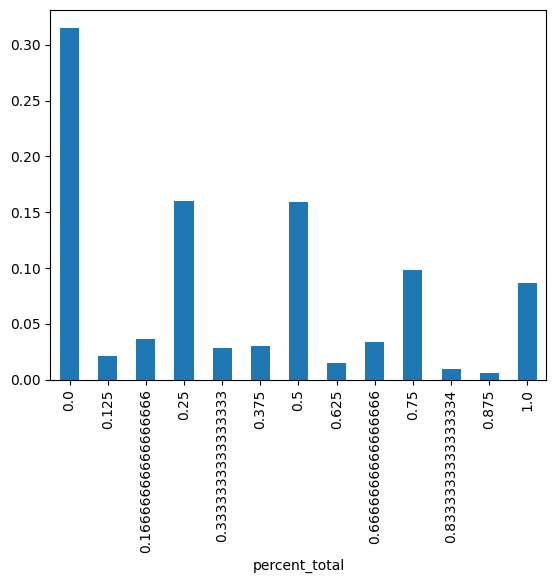

In [22]:


human_descriptives_df = human_descriptives_df.merge(
    max_scores,
    on="question_id",
    how="left"
)

human_descriptives_df["percent_total"] = human_descriptives_df["marker_score"] / human_descriptives_df["max_score"]
human_descriptives_df["percent_total"].unique()

proportions = (
    human_descriptives_df["percent_total"]
    .value_counts(normalize=True)
    .sort_index()
)

proportions.plot(kind='bar')
print(f"Proportions:{proportions}")
human_descriptives_df["percent_total"].describe()
included_questions = human_descriptives_df["question_id"].unique()
print(f"included questions: {included_questions}")


In [23]:
human_descriptives_df["percent_total"].median()

np.float64(0.25)

# Model calls to native LLM (i.e. model which has not been fine-tuned) 

Retrieve API key from .env and instantiate client

In [7]:
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
#print(openai_api_key[:5], "******", openai_api_key[-5:])
client = OpenAI()

Define function to make model calls

In [12]:
def call_llm(
        jsonl_file,
        main_data_df,
        client,
        model="gpt-4.1-mini",
        interim_out_dir="interim_outputs",
        final_csv_suffix=""
    ):

    """
    Takes in a JSONL file of either zero shot or few shot data
    Calls the OpenAI Responses API with each parsed JSON
    Handles multiple formats of API response to either parse response to 
    valid json or ultimately to save raw output
    Unpacks response JSON into a dataframe
    Saves each dataframe row sequentially to csv
    Calls align_tidy_outputs to clean up dataframe.
    """

    dataset = jsonl_file.stem
    rows = []

    class OutputSchema(BaseModel):
        student_id: Union [str, int]
        question_id: Union [str, int]
        marker_score: float = Field(ge=0)
        max_score: float = Field(ge=0)
        marker_feedback: str #= Field(max_length=300)

    REQUIRED = {"student_id", "question_id", "marker_score", "max_score", "marker_feedback"}

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            messages = obj["messages"]

            # ---- call + parse with fallback ----
            parsed = {}
            raw = ""
            try:
                response = client.responses.parse(
                    model=model,
                    input=messages,
                    max_output_tokens=600,
                    text_format=OutputSchema,
                )
                raw = response.output_text

                parsed_obj = response.output_parsed         # pydantic object containing structured responses as attributes
                if parsed_obj is not None:
                    parsed = parsed_obj.model_dump()        # parsed should now be type(dict)
                    print(f"Route A: row {i} successfully parsed and validated from responses.parse call")
                else:
                    try:
                        cleaned = clean_json_text(raw)      # strips spurious fencing characters if present
                        parsed_obj = OutputSchema.model_validate_json(cleaned)  # creates and validates output as pydantic obj
                        parsed = parsed_obj.model_dump()    # parsed should now be type(dict)
                        print(f"Route B: row {i} recoverd, validated and parsed from raw ouput after responses.parse call")
                    except ValidationError as e:
                        try: 
                           cleaned = clean_json_text(raw)
                           parsed = json.loads(raw)         # attempts to parse json string as dict
                           print(f"Route C due to {e} row {i} recovered from raw and parsed to dict without validation after responses.parse call. ")

                        except Exception as e2:
                            print(f"Route D due to {e2}: row {i}: unable to parse row to dict from json_text after responses.parse call: Raw saved ")
                            parsed = {}
                            raw = raw or "No raw output available"



            except ValidationError as e3:        # My hypothesis is that with the above, this whole section never required
                # parse() can raise if JSON is truncated/invalid; fall back to create()
                print(f"Responses.CREATE call after exception {e3}. Row {i}: failed with responses.parse call.")
                response = client.responses.create(
                    model=model,
                    input=messages,
                    max_output_tokens=600,
                )
                raw = response.output_text
                try:
                    cleaned = clean_json_text(raw)
                    parsed_obj = OutputSchema.model_validate_json(cleaned)
                    parsed = parsed_obj.model_dump()
                    print(f"Route E: row {i} successfully cleaned, validated and parsed to dict from responses.create call")
                except Exception as e4:
                    try: 
                           cleaned = clean_json_text(raw)
                           parsed = json.loads(raw)         # attempts to parse json string as dict
                           print(f"Route F due to {e4}. Row {i}: recovered from raw and parsed to dict without validation after responses.create call. ")

                    except Exception as e5:
                            print(f"Route G due to {e5}: row {i}: unable to parse row to dict from json_text after responses.create call. Raw saved")
                            parsed = {}
                            raw = raw or "No raw output available"

                    print(f"clean or fallback validation failed: ")
                    parsed = {}
                    raw = raw or "No raw output available"

            

            # Parse_Ok True only if all required keys are present
            parse_ok = isinstance(parsed, dict) and REQUIRED.issubset(parsed)

            # ---- usage ----
            try:
                usage = getattr(response, "usage", None)
                input_tokens = getattr(usage, "input_tokens", None) if usage else None
                output_tokens = getattr(usage, "output_tokens", None) if usage else None
                total_tokens = (input_tokens + output_tokens) if (input_tokens is not None and output_tokens is not None) else None
            except Exception:
                input_tokens = output_tokens = total_tokens = None

            # ---- build row (will not crash even if parsed == {}) ----
            row = {
                "Dataset": dataset,
                "Student_ID": parsed.get("student_id"),
                "Question_ID": parsed.get("question_id"),
                "Model_score": parsed.get("marker_score"),
                "Model_feedback": parsed.get("marker_feedback"),
                "Token_count": total_tokens,
                "Input_tokens": input_tokens,
                "Output_tokens": output_tokens,
                "Log_Probs": None,
                "Raw_output": raw,
                "Model": model,
                "Timestamp_UTC": datetime.utcnow().isoformat(),
                "Row_Index": i,
                "Parse_Ok": parse_ok,
            }

            try:
                save_row_to_csv(dataset, row, out_dir=interim_out_dir)
            except Exception as e:
                print("unable to save row", e)

            if not parse_ok:
                print(f"WARNING: JSON parse failed on row {i}; output_tokens={output_tokens}")
                with open(f"{dataset}_parse_errors.jsonl", "a", encoding="utf-8") as ef:
                    ef.write(json.dumps({"row_index": i, "row_output": raw}, ensure_ascii=False) + "\n")

            rows.append(row)

    model_responses_interim = pd.DataFrame(rows)

    try:
        output_df = align_tidy_outputs(model_responses_interim, main_data_df)
        output_filename = dataset + final_csv_suffix + ".csv"
        output_file_path = cwd / "model_outputs" / output_filename
        output_df.to_csv(output_file_path, index=False)
        return output_df
    except Exception as e:
        print("WARNING: alignment failed, returning interim outputs. Error:", e)
        return model_responses_interim

Helper functions to assist model call function

In [9]:
def save_row_to_csv(dataset, row, out_dir="interim_outputs"):
    """
    Append a single row to a condition-specific CSV file.
    Adds header if needed.
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    path = out_dir / f"{dataset}_interim.csv"
    write_header = (not path.exists()) or (path.stat().st_size == 0)

    with path.open("a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            writer.writeheader()
        writer.writerow(row)


In [10]:
def align_tidy_outputs(model_responses, main_data_df):

    """ 
    Takes 2 Pandas dataframes as input:
        - model_responses
        - main_data_df

    Functions:
    -obtains human scores and feedback from main_data_df
    -merges human scores and feedback with models scores and feedback
    -checks alignment of identifiers for model and human data
    -drops duplicate columns if aligned
    -returns cleaned model responses containing aligned human data
    """
    
    # convert references to strings
    model_responses["Student_ID"] = model_responses["Student_ID"].astype(str)
    model_responses["Question_ID"] = model_responses["Question_ID"].astype(str)

    main_data_df["student_id"] = main_data_df["student_id"].astype(str)
    main_data_df["question_id"] = main_data_df["question_id"].astype(str)

    # merge
    model_responses = model_responses.merge(
    main_data_df[["student_id", "question_id", "marker_score", "marker_feedback"]],
    left_on=["Student_ID", "Question_ID"],
    right_on=["student_id", "question_id"],
    how="left"
    )

    # rename columns
    model_responses = model_responses.rename(
    columns={"marker_score": "Human_Marker_Score"}
    )
    model_responses = model_responses.rename(
        columns={"marker_feedback": "Human_Marker_Feedback"}
    )

    # check alignment
    stud_id_model = pd.to_numeric(model_responses["Student_ID"], errors="coerce")
    stud_id_human = pd.to_numeric(model_responses["student_id"], errors="coerce")

    model_responses["Compare_Student_IDs"] = stud_id_model - stud_id_human

    q_id_model = pd.to_numeric(model_responses["Question_ID"], errors="coerce")
    q_id_human = pd.to_numeric(model_responses["question_id"], errors="coerce")

    model_responses["Compare_Question_IDs"] = q_id_model - q_id_human

    # drop surplus columns if aligned
    if (model_responses["Compare_Student_IDs"] == 0).all():
        model_responses = model_responses.drop(columns=["Compare_Student_IDs", "question_id"])

    else:
        print("WARNING: misalignment in Compare Student IDs ")

    if (model_responses["Compare_Question_IDs"] == 0).all():
        model_responses = model_responses.drop(columns=["Compare_Question_IDs", "student_id"])

    else:
        print("WARNING: misalignment in Compare Question IDs ")

    model_responses["Model-Human Delta"] = model_responses["Model_score"] - model_responses["Human_Marker_Score"]

    return model_responses


In [11]:
def clean_json_text(raw: str) -> str:
    if not raw:
        return raw

    s = raw.strip()

    # Remove markdown code fences like ```json ... ``` or ``` ... ```
    s = re.sub(r"^\s*```(?:json)?\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s*```\s*$", "", s)

    # Remove prefixes like ///json, //json, json, JSON
    s = re.sub(r"^\s*/{2,}\s*json\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"^\s*json\s*", "", s, flags=re.IGNORECASE)

    # Keep only the outermost JSON object if extra text remains
    start = s.find("{")
    end = s.rfind("}")
    if start != -1 and end != -1 and end > start:
        s = s[start:end + 1]

    return s.strip()

Zero shot call to base (non-fine tuned) model

In [13]:
jsonl_testing_zs = cwd / "jsonl_files" / "testing_zero_shot.jsonl"
testing_zs_output = call_llm (
    jsonl_testing_zs, 
    main_data_df, client, 
    model="gpt-4.1-mini-2025-04-14", 
    interim_out_dir = "interim_outputs", 
    final_csv_suffix = "_base_v2")

Route A: row 0 successfully parsed and validated from responses.parse call


C:\Users\hfk66\AppData\Local\Temp\ipykernel_29424\4289340720.py:132: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "Timestamp_UTC": datetime.utcnow().isoformat(),


Route A: row 1 successfully parsed and validated from responses.parse call
Route A: row 2 successfully parsed and validated from responses.parse call
Route A: row 3 successfully parsed and validated from responses.parse call
Route A: row 4 successfully parsed and validated from responses.parse call
Route A: row 5 successfully parsed and validated from responses.parse call
Route A: row 6 successfully parsed and validated from responses.parse call
Route A: row 7 successfully parsed and validated from responses.parse call
Route A: row 8 successfully parsed and validated from responses.parse call
Route A: row 9 successfully parsed and validated from responses.parse call
Route A: row 10 successfully parsed and validated from responses.parse call
Route A: row 11 successfully parsed and validated from responses.parse call
Route A: row 12 successfully parsed and validated from responses.parse call
Route A: row 13 successfully parsed and validated from responses.parse call
Route A: row 14 succe

In [ ]:
testing_zs_output

Few shot call to base (non-fine_tuned) model

In [15]:
jsonl_testing_fs = cwd / "jsonl_files" / "testing_few_shot.jsonl"
testing_few_shot_output = call_llm (
    jsonl_testing_fs, 
    main_data_df, client, 
    model="gpt-4.1-mini-2025-04-14", 
    interim_out_dir = "interim_outputs", 
    final_csv_suffix = "_base_v2")

Route A: row 0 successfully parsed and validated from responses.parse call


C:\Users\hfk66\AppData\Local\Temp\ipykernel_29424\4289340720.py:132: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "Timestamp_UTC": datetime.utcnow().isoformat(),


Route A: row 1 successfully parsed and validated from responses.parse call
Route A: row 2 successfully parsed and validated from responses.parse call
Route A: row 3 successfully parsed and validated from responses.parse call
Route A: row 4 successfully parsed and validated from responses.parse call
Route A: row 5 successfully parsed and validated from responses.parse call
Route A: row 6 successfully parsed and validated from responses.parse call
Route A: row 7 successfully parsed and validated from responses.parse call
Route A: row 8 successfully parsed and validated from responses.parse call
Route A: row 9 successfully parsed and validated from responses.parse call
Route A: row 10 successfully parsed and validated from responses.parse call
Route A: row 11 successfully parsed and validated from responses.parse call
Route A: row 12 successfully parsed and validated from responses.parse call
Route A: row 13 successfully parsed and validated from responses.parse call
Route A: row 14 succe

# Supervised fine-tuning of model

In [16]:
# # instantiate client and create fine-tuning data files
ft_client = OpenAI()


train_path = cwd / "jsonl_files" / "training_data_fine_tune_scores_only.jsonl"
train_file = ft_client.files.create(
    file=open(train_path, "rb"),
    purpose="fine-tune",
)

validation_path = cwd / "jsonl_files" / "validation_data_fine_tune_scores_only.jsonl"
validation_file = ft_client.files.create(
    file=open(validation_path, "rb"),
    purpose="fine-tune",
)

In [17]:
print(train_file.id, validation_file.id)

Run Fine Tuning job

In [18]:
# Full fine tuning
finetune_job = ft_client.fine_tuning.jobs.create(
    model="gpt-4.1-mini-2025-04-14",
    training_file=train_file.id,
    validation_file=validation_file.id,
    hyperparameters={
        "n_epochs": 5,
        "learning_rate_multiplier": 1.0,
        #"batch_size": "auto",
    },
    suffix="SAQyr1_may2022_ft_SCORES_ONLY_model_v1_16Apr26"
)

In [19]:
print(finetune_job.id, finetune_job.status)

# Model calls to  fine-tuned LLM

In [20]:
#v1_ft_model = "ft:gpt-4.1-mini-2025-04-14:personal:yr1-may2022-ft-model-full-data:Cv8k6ooy"
#v2_ft_model = "ft:gpt-4.1-mini-2025-04-14:personal:saqyr1-may2022-ft-model-v1-12mar26:DKUArs7Q"
scores_only_ft_model = "ft:gpt-4.1-mini-2025-04-14:personal:saqyr1-may2022-ft-scores-only-model-v1-16apr26:DXUAfSuF"

Zero shot call to fine-tuned LLM 

In [22]:
jsonl_testing_zs = cwd / "jsonl_files" / "testing_zero_shot.jsonl"
testing_fine_tune_zs_output = call_llm (
    jsonl_testing_zs, 
    main_data_df, client, 
    model= scores_only_ft_model,  
    interim_out_dir = "interim_outputs", 
    final_csv_suffix = "_FTscores_zs_v1")

Route A: row 0 successfully parsed and validated from responses.parse call


C:\Users\hfk66\AppData\Local\Temp\ipykernel_29424\4289340720.py:132: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "Timestamp_UTC": datetime.utcnow().isoformat(),


Route A: row 1 successfully parsed and validated from responses.parse call
Route A: row 2 successfully parsed and validated from responses.parse call
Route A: row 3 successfully parsed and validated from responses.parse call
Route A: row 4 successfully parsed and validated from responses.parse call
Route A: row 5 successfully parsed and validated from responses.parse call
Route A: row 6 successfully parsed and validated from responses.parse call
Route A: row 7 successfully parsed and validated from responses.parse call
Route A: row 8 successfully parsed and validated from responses.parse call
Route A: row 9 successfully parsed and validated from responses.parse call
Route A: row 10 successfully parsed and validated from responses.parse call
Route A: row 11 successfully parsed and validated from responses.parse call
Route A: row 12 successfully parsed and validated from responses.parse call
Route A: row 13 successfully parsed and validated from responses.parse call
Route A: row 14 succe

Few shot call to fine-tuned LLM

In [25]:
jsonl_testing_fs = cwd / "jsonl_files" / "testing_few_shot.jsonl"
testing_fine_tune_fs_output = call_llm(
    jsonl_testing_fs,
    main_data_df, client,
    model=scores_only_ft_model,
    interim_out_dir= "interim_outputs",
    final_csv_suffix= "FTscores_fsv1"
)

Route A: row 0 successfully parsed and validated from responses.parse call


C:\Users\hfk66\AppData\Local\Temp\ipykernel_29424\4289340720.py:132: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "Timestamp_UTC": datetime.utcnow().isoformat(),


Route A: row 1 successfully parsed and validated from responses.parse call
Route A: row 2 successfully parsed and validated from responses.parse call
Route A: row 3 successfully parsed and validated from responses.parse call
Route A: row 4 successfully parsed and validated from responses.parse call
Route A: row 5 successfully parsed and validated from responses.parse call
Route A: row 6 successfully parsed and validated from responses.parse call
Route A: row 7 successfully parsed and validated from responses.parse call
Route A: row 8 successfully parsed and validated from responses.parse call
Route A: row 9 successfully parsed and validated from responses.parse call
Route A: row 10 successfully parsed and validated from responses.parse call
Route A: row 11 successfully parsed and validated from responses.parse call
Route A: row 12 successfully parsed and validated from responses.parse call
Route A: row 13 successfully parsed and validated from responses.parse call
Route A: row 14 succe

In [26]:
# testing_fine_tune_fs_output

# Evaluation of LLM outputs

Define function to calculate evaluation metrics

In [42]:
# reload output data if required
cwd = Path.cwd()
zero_shot_output_path = cwd / "model_outputs" / "testing_zero_shot_base_v2.csv"
few_shot_output_path = cwd / "model_outputs" / "testing_few_shot_base_v2.csv"
FTscores_zero_shot_output_path = cwd / "model_outputs" / "testing_zero_shot_FTscores_zs_v1.csv"
FTscores_few_shot_output_path = cwd / "model_outputs" / "testing_few_shotFTscores_fsv1.csv"



In [43]:
zero_shot_output_df = pd.read_csv(zero_shot_output_path)
few_shot_output_df = pd.read_csv(few_shot_output_path)
FTscores_zero_shot_output_df = pd.read_csv(FTscores_zero_shot_output_path)
FTscores_few_shot_output_df = pd.read_csv(FTscores_few_shot_output_path)

In [ ]:
# inspect for missing data due to parsing errors -> rows 79 and 429 "Human marker score" and "Human marker feedback" missing and filled manuaully
missing_human = FTscores_zero_shot_output_df[
    FTscores_zero_shot_output_df["Human_Marker_Score"].isna()
]

missing_human

In [29]:
model_raw_scores = FTscores_zero_shot_output_df["Model_score"].unique()
print(model_raw_scores)


[0.    0.5   1.    1.01  1.02  1.5   2.55  1.05  2.    2.05  2.02  1.51
 2.5   2.51  3.02  3.    2.53  1.52  0.52  0.01  0.51  0.55  0.53  1.07
 1.56  3.5   1.55  2.01  2.03  0.06  0.02  1.03  2.52  1.04  3.05  1.512]


In [30]:
# define list of output dataframes
results_list = [zero_shot_output_df, few_shot_output_df, FTscores_zero_shot_output_df, FTscores_few_shot_output_df]

In [31]:
# As model raw scores contains unexpected values, round to nearest half mark:
def round_to_half(x):
    return round(float(x) * 2) / 2


In [32]:
# round model scores to nearest half mark
for df in results_list:     # most recently I substituted results list for [zero_shot_output_df, few_shot_output_df] to just fill in for new dfs
    df["Model_score_ROUNDED"] = df["Model_score"].apply(round_to_half)


In [33]:
FTscores_few_shot_output_df.columns

Index(['Dataset', 'Student_ID', 'Question_ID', 'Model_score', 'Model_feedback',
       'Token_count', 'Input_tokens', 'Output_tokens', 'Log_Probs',
       'Raw_output', 'Model', 'Timestamp_UTC', 'Row_Index', 'Parse_Ok',
       'Human_Marker_Score', 'Human_Marker_Feedback', 'Model-Human Delta',
       'Model_score_ROUNDED'],
      dtype='str')

In [34]:
# Check maximum magnitude of rounding:
for idx, df in enumerate(results_list):
    delta = (df["Model_score_ROUNDED"] - df["Model_score"]).abs()
    max_idx = delta.idxmax()
    max_delta = delta.loc[max_idx]
    
    print(f"DF {idx}: max delta = {max_delta}")
    print(df.loc[max_idx, ["Model_score", "Model_score_ROUNDED"]])

DF 0: max delta = 0.25
Model_score            1.25
Model_score_ROUNDED    1.00
Name: 142, dtype: float64
DF 1: max delta = 0.0
Model_score            1.0
Model_score_ROUNDED    1.0
Name: 0, dtype: float64
DF 2: max delta = 0.07000000000000006
Model_score            1.07
Model_score_ROUNDED    1.00
Name: 391, dtype: float64
DF 3: max delta = 0.07000000000000006
Model_score            1.07
Model_score_ROUNDED    1.00
Name: 287, dtype: float64


In [35]:
# Persist rounded scores 
zero_shot_output_df.to_csv(zero_shot_output_path, index=False)
few_shot_output_df.to_csv(few_shot_output_path, index=False)
FTscores_zero_shot_output_df.to_csv(FTscores_zero_shot_output_path, index=False)
FTscores_few_shot_output_df.to_csv(FTscores_few_shot_output_path, index=False)

In [36]:
def calc_eval_metrics(
    data_frame,
    name: str = "",
    target: str = "",
    predicted: str = "",
    bootstrap: bool = False,
    n_boot: int = 5000,
    ci: float = 0.95,
    random_state: int | None = None,
    adj_accuracy_delta: float =0.5,
    ):
    """
    data_frame: single df containing BOTH target (ground truth) and predicted (model estimate) as aligned columns
    name: label for output
    target: column name of ground-truth
    predicted: column name of predictions
    bootstrap: if True, compute percentile bootstrap CI
    n_boot: number of bootstrap resamples
    ci: confidence level (e.g., 0.95)
    adj_accuracy_delta: magnitude of difference between pred and target considered adjacent
    """

    df = data_frame.copy()
    if name == "" and "Dataset" in df.columns:
        name = str(df["Dataset"].iloc[0])

    questions = df["Question_ID"].unique().tolist()
    print(questions)

    target_col = target
    pred_col = predicted

    def adjacent_accuracy(human, model, delta=0.5):
        valid = human.notna() & model.notna()
        if valid.sum() == 0:
            return np.nan

        return (human[valid].sub(model[valid]).abs() <= delta).mean()

    def calc(data: pd.DataFrame, question_label: str, name: str, bootstrap: bool = False):
        y_true = data[target_col]
        y_pred = data[pred_col]

        # t_string = y_true.astype(str)
        # pred_string = y_pred.astype(str)

        y_true_num = pd.to_numeric(y_true, errors="coerce") # convert to numeric to align interger and float values in model output
        y_pred_num = pd.to_numeric(y_pred, errors="coerce")

        y_true_label = y_true_num.astype(float).astype(str) # then back to string to align with sklearn input format
        y_pred_label = y_pred_num.astype(float).astype(str)

        exact_acc = accuracy_score(y_true_label, y_pred_label)
        adjacent_acc = adjacent_accuracy(y_true_num, y_pred_num, delta=adj_accuracy_delta)
        mae = mean_absolute_error(y_true_num, y_pred_num)
        qwk = cohen_kappa_score(y_true_label, y_pred_label, weights="quadratic")

        result = pd.DataFrame([{
            "name": name,
            "question": question_label,
            "exact accuracy": exact_acc,
            "adjacent accuracy": adjacent_acc,
            "mean abs error": mae,
            "quad weighted kappa": qwk
        }])

        if bootstrap:
            exact_acc_low, exact_acc_high, adjacent_acc_low, adjacent_acc_high, mae_low, mae_high, qwk_low, qwk_high = bootstrap_conf_interv(
                data=data,
                question_label=question_label,
                name=name,
                n=n_boot,
                ci=ci,
                random_state=random_state
            )

            result["exact_acc_low"] = exact_acc_low
            result["exact_acc_high"] = exact_acc_high
            result["adjacent_acc_low"] = adjacent_acc_low
            result["adjacent_acc_high"] = adjacent_acc_high
            result["mae_low"] = mae_low
            result["mae_high"] = mae_high
            result["qwk_low"] = qwk_low
            result["qwk_high"] = qwk_high

        return result

    def bootstrap_conf_interv(
        data: pd.DataFrame,
        question_label: str,
        name: str,
        n: int = 5000,
        ci: float = 0.95,
        random_state: int | None = None,
    ):
        interim_results = []

        alpha = (1.0 - ci) / 2.0
        low_q = alpha
        high_q = 1.0 - alpha

        for i in range(n):
            sampled_replace = data.sample(
                n=len(data),
                replace=True,
                random_state=(None if random_state is None else random_state + i)
            )

            one = calc(sampled_replace, question_label, name, bootstrap=False)
            interim_results.append(one)

        metric_results = pd.concat(interim_results, ignore_index=True)

        exact_acc_low = metric_results["exact accuracy"].quantile(low_q)
        exact_acc_high = metric_results["exact accuracy"].quantile(high_q)
        adjacent_acc_low = metric_results["adjacent accuracy"].quantile(low_q)
        adjacent_acc_high = metric_results["adjacent accuracy"].quantile(high_q)
        mae_low = metric_results["mean abs error"].quantile(low_q)
        mae_high = metric_results["mean abs error"].quantile(high_q)
        qwk_low = metric_results["quad weighted kappa"].quantile(low_q)
        qwk_high = metric_results["quad weighted kappa"].quantile(high_q)

        return (
            exact_acc_low,
            exact_acc_high,
            adjacent_acc_low,
            adjacent_acc_high,
            mae_low,
            mae_high,
            qwk_low,
            qwk_high
        )

    results = [calc(df, "overall", name, bootstrap=bootstrap)]

    for question in questions:
        q_df = df[df["Question_ID"] == question]
        results.append(calc(q_df, question, name, bootstrap=bootstrap))

    result_df = pd.concat(results, ignore_index=True)
    return result_df

In [42]:
zs_metrics_path = cwd / "evaluation" / "zero_shot_metrics_v4.csv"
fs_metrics_path = cwd / "evaluation" / "few_shot_metrics_v4.csv"
FTscores_zs_metrics_path = cwd / "evaluation" / "FTscores_zs_metrics_v4.csv"
FTscores_fs_metrics_path = cwd / "evaluation" / "FTscores_fs_metrics_v4.csv"


In [64]:
#Calculate evaluation metrics for each model output dataframe

zero_shot_metrics = calc_eval_metrics(
    data_frame=zero_shot_output_df,
    name = "ZeroShotv1_gpt-4.1-mini-2025-04-14",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
zero_shot_metrics.to_csv(zs_metrics_path, index=False)

few_shot_metrics = calc_eval_metrics(
    data_frame=few_shot_output_df,
    name = "FewShotv1_gpt-4.1-mini-2025-04-14",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
few_shot_metrics.to_csv(fs_metrics_path, index=False)

FT_zero_shot_metrics = calc_eval_metrics(
    data_frame=FTscores_zero_shot_output_df,
    name = "FTscores_zero_Shot_v1_ft_model:scores_only_DXUAfSuF",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
FT_zero_shot_metrics.to_csv(FTscores_zs_metrics_path, index=False)

FT_few_shot_metrics = calc_eval_metrics(
    data_frame=FTscores_few_shot_output_df,
    name = "FTscores_few_Shot_v1_ft_model:scores_only_DXUAfSuF",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
FT_few_shot_metrics.to_csv(FTscores_fs_metrics_path,index=False)
# 
# FT_zero_shot_output_df 
# FT_few_shot_output_df 

[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19]


c:\Users\hfk66\OneDrive - University of Keele\Current Research\Automatic SAQ Marking\Fine-tuning project\v3\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\hfk66\OneDrive - University of Keele\Current Research\Automatic SAQ Marking\Fine-tuning project\v3\venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)


[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19]


In [43]:
# Reload metrics dataframes if restarting:
zero_shot_metrics = pd.read_csv(zs_metrics_path)
few_shot_metrics = pd.read_csv(fs_metrics_path)
FT_zero_shot_metrics = pd.read_csv(FTscores_zs_metrics_path)
FT_few_shot_metrics = pd.read_csv(FTscores_fs_metrics_path)

In [15]:
metric_df_names = ["zero_shot_metrics", "few_shot_metrics", "FT_zero_shot_metrics", "FT_few_shot_metrics"]

In [15]:
zero_shot_output_df.columns

Index(['Dataset', 'Student_ID', 'Question_ID', 'Model_score', 'Model_feedback',
       'Token_count', 'Input_tokens', 'Output_tokens', 'Log_Probs',
       'Raw_output', 'Model', 'Timestamp_UTC', 'Row_Index', 'Parse_Ok',
       'student_id', 'question_id', 'Human_Marker_Score',
       'Human_Marker_Feedback', 'Compare_Student_IDs', 'Compare_Question_IDs',
       'Model-Human Delta', 'Model_score_ROUNDED'],
      dtype='str')

In [65]:
def calc_cronbach(
    df: pd.DataFrame | list[pd.DataFrame],
    name: str | list[str] = "",
    human: bool | list[bool] = True
):
    # Convert single inputs into lists
    list_df = df if isinstance(df, list) else [df]
    list_name = name if isinstance(name, list) else [name]
    list_human = human if isinstance(human, list) else [human]

    rows = []

    for idx, current_df in enumerate(list_df):

        current_name = list_name[idx]
        current_human = list_human[idx]

        score_col = "Human_Marker_Score" if current_human else "Model_score_ROUNDED"

        temp_df = current_df.copy()
        temp_df[score_col] = temp_df[score_col].astype(float)

        wide_df = temp_df.pivot(
            index="Student_ID",
            columns="Question_ID",
            values=score_col
        )

        cronbach, conf_int = pg.cronbach_alpha(wide_df)

        rows.append({
            "dataset": current_name,
            "cronbach": cronbach,
            "lower_ci": conf_int[0],
            "upper_ci": conf_int[1]
        })

    cronbach_df = pd.DataFrame(rows)
    return cronbach_df

In [17]:
metrics_df_list = [zero_shot_metrics, few_shot_metrics, FT_zero_shot_metrics, FT_few_shot_metrics]

In [18]:
overall_rows = []

for idx, df in enumerate(metrics_df_list):
    overall = df[df["question"] == "overall"]
    overall_rows.append(overall)

combined_overall_df = pd.concat(overall_rows, ignore_index=True)

In [22]:
df = pd.read_csv(cwd / "model_outputs" / "testing_zero_shot_base_v2.csv")
df.columns

Index(['Dataset', 'Student_ID', 'Question_ID', 'Model_score', 'Model_feedback',
       'Token_count', 'Input_tokens', 'Output_tokens', 'Log_Probs',
       'Raw_output', 'Model', 'Timestamp_UTC', 'Row_Index', 'Parse_Ok',
       'Human_Marker_Score', 'Human_Marker_Feedback', 'Model-Human Delta',
       'Model_score_ROUNDED'],
      dtype='str')

In [19]:
combined_overall_df

,name,question,exact accuracy,adjacent accuracy,mean abs error,quad weighted kappa,exact_acc_low,exact_acc_high,adjacent_acc_low,adjacent_acc_high,mae_low,mae_high,qwk_low,qwk_high
0,ZeroShotv1_gpt-4.1-mini-2025-04-14,overall,0.403651,0.770791,0.473631,0.675252,0.373225,0.434102,0.744422,0.797160,0.440669,0.506085,0.638913,0.708200
1,FewShotv1_gpt-4.1-mini-2025-04-14,overall,0.455375,0.835700,0.398073,0.740380,0.424949,0.486815,0.811359,0.859026,0.368661,0.427992,0.708355,0.770471
2,FTscores_zero_Shot_v1_ft_model:scores_only_DXU...,overall,0.680527,0.973631,0.173935,0.915926,0.651116,0.709939,0.962475,0.983773,0.157201,0.191176,0.903091,0.927841
3,FTscores_few_Shot_v1_ft_model:scores_only_DXUA...,overall,0.648073,0.958418,0.199290,0.899930,0.619650,0.677485,0.946247,0.970588,0.181542,0.217039,0.885769,0.912850


In [20]:
combined_overall_df.to_csv(cwd / "evaluation" / "overall_metrics_by_alignment_method.csv")

In [70]:
names= ["human","zero_shot", "few_shot", "fine tuned zero shot", "fine tuned few shot"]
results_list = [zero_shot_output_df, zero_shot_output_df, few_shot_output_df, FTscores_zero_shot_output_df, FTscores_few_shot_output_df]
human_list = [True, False, False, False, False]
cronbach_df = calc_cronbach(results_list, names, human_list)
cronbach_df.to_csv(cwd / "evaluation" / "cronbach.csv")
cronbach_df


,dataset,cronbach,lower_ci,upper_ci
0,human,0.823129,0.749,0.883
1,zero_shot,0.828488,0.757,0.887
2,few_shot,0.826962,0.755,0.886
3,fine tuned zero shot,0.849261,0.786,0.900
4,fine tuned few shot,0.852688,0.791,0.903


In [71]:
# persist metrics
zero_shot_metrics.to_csv(zs_metrics_path, index=False) 
few_shot_metrics.to_csv(fs_metrics_path, index=False)
FT_zero_shot_metrics.to_csv(FTscores_zs_metrics_path, index=False) 
FT_few_shot_metrics.to_csv(FTscores_fs_metrics_path, index=False) 

In [73]:
def plot_confusion_matrices(
    df: pd.DataFrame | list[pd.DataFrame],
    target: str,
    predicted: str,
    name: str | list[str] = "",
    normalize: str | None = None,   # None, "true", "pred", "all"
    max_cols: int = 2,
    save_prefix: str | None = None,
):
    """
    Plot confusion matrices for one or more DataFrames.

    Parameters
    ----------
    df:
        A single DataFrame or a list of DataFrames.
    target:
        Column containing true labels.
    predicted:
        Column containing predicted labels.
    name:
        A single name or list of names for subplot titles.
    normalize:
        Passed to sklearn.metrics.confusion_matrix.
        Options: None, "true", "pred", "all".
    max_cols:
        Maximum number of subplot columns.
    save_prefix:
        If set, saves the figure as f"{save_prefix}_confusion_matrices.png".
    """

    # Ensure df_list is always a list
    if isinstance(df, pd.DataFrame):
        df_list = [df]
    elif isinstance(df, list):
        df_list = df
    else:
        raise TypeError("df must be a pandas DataFrame or a list of DataFrames")

    n_plots = len(df_list)

    # Ensure name_list is always a list of matching length
    if isinstance(name, str):
        name_list = [name] * n_plots
    elif isinstance(name, list):
        name_list = name
    else:
        raise TypeError("name must be a string or a list of strings")

    if len(name_list) != n_plots:
        raise ValueError("name must be a single string or a list with the same length as df")

    # Work out subplot grid dimensions
    n_cols = min(max_cols, n_plots)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )

    # Make axes iterable even if there is only one subplot
    axes = np.array(axes).reshape(-1)

    for idx, current_df in enumerate(df_list):
        data = current_df.copy()

        y_true = data[target]
        y_pred = data[predicted]

        # Drop rows where either true or predicted value is missing
        mask = pd.notna(y_true) & pd.notna(y_pred)
        y_true = y_true.loc[mask].astype(str)
        y_pred = y_pred.loc[mask].astype(str)

        # Consistent labels for this matrix
        labels = np.sort(np.unique(np.concatenate([y_true.values, y_pred.values])))

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels,
            normalize=normalize
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=labels
        )

        disp.plot(
            ax=axes[idx],
            cmap="Blues",
            #norm=LogNorm(),
            values_format=".2f" if normalize else "d",
            colorbar=False
        )

        title = name_list[idx] if name_list[idx] else f"Confusion matrix {idx + 1}"
        axes[idx].set_title(title)

    # Hide unused subplots
    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_confusion_matrices.png", dpi=300, bbox_inches="tight")

    plt.show()

In [74]:
from matplotlib.colors import LogNorm

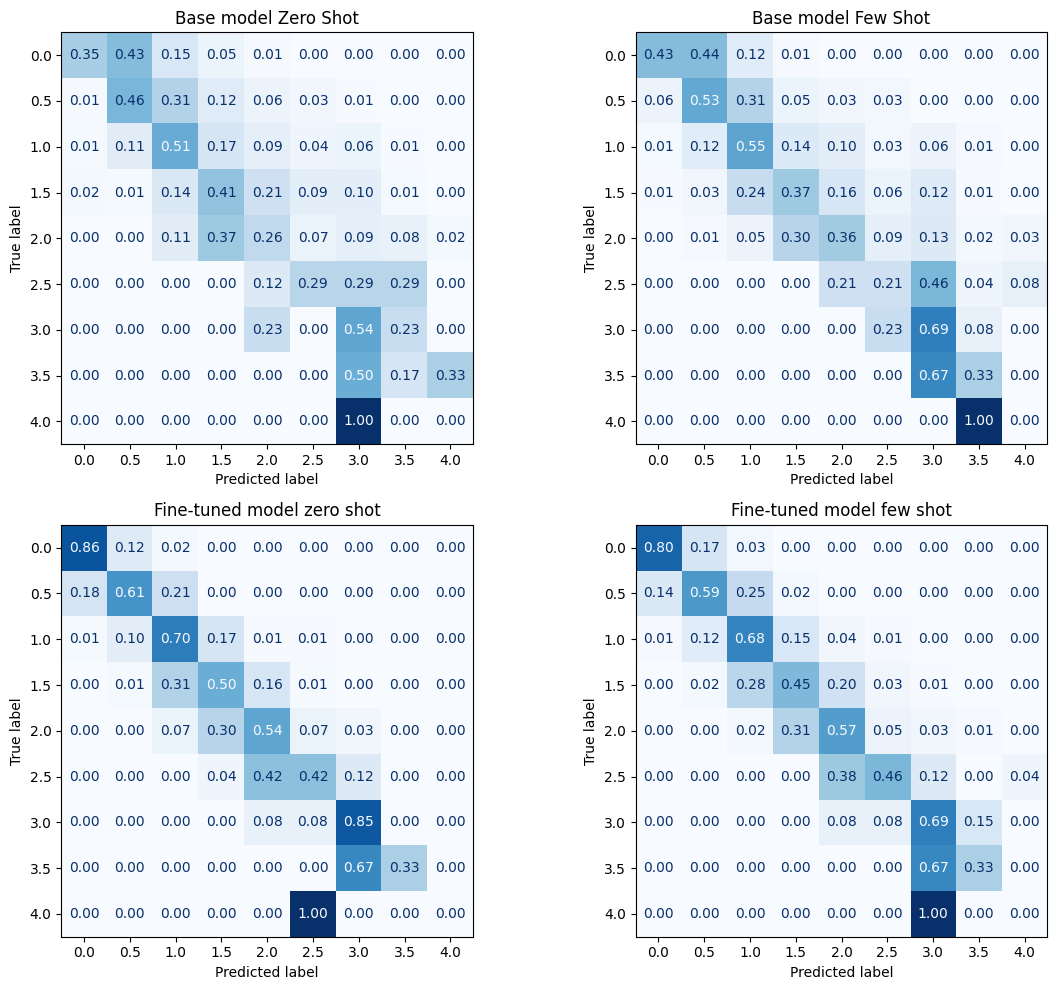

In [75]:
results_list = [zero_shot_output_df, few_shot_output_df, FTscores_zero_shot_output_df, FTscores_few_shot_output_df] 
plot_confusion_matrices(
    df=results_list, 
    target= "Human_Marker_Score",
    predicted= "Model_score_ROUNDED",
    name= ["Base model Zero Shot", "Base model Few Shot", "Fine-tuned model zero shot", "Fine-tuned model few shot"],
    normalize= 'true',            #None, "true", "pred", "all"
    max_cols= 2,
    save_prefix= "Confusion Model Plots",
)

In [45]:
zero_shot_metrics.columns

Index(['name', 'question', 'exact accuracy', 'adjacent accuracy',
       'mean abs error', 'quad weighted kappa', 'exact_acc_low',
       'exact_acc_high', 'adjacent_acc_low', 'adjacent_acc_high', 'mae_low',
       'mae_high', 'qwk_low', 'qwk_high'],
      dtype='str')

In [48]:
QWK_comparison_across_conditions = zero_shot_metrics[["question", "quad weighted kappa", "qwk_low", "qwk_high"]].rename(columns={"quad weighted kappa": "Base zero_shot", "qwk_low":"zs_low", "qwk_high":"zs_high"})
QWK_comparison_across_conditions

,question,Base zero_shot,zs_low,zs_high
0,overall,0.675252,0.638913,0.708200
1,1,0.517195,0.377128,0.628059
2,3,0.783447,0.651745,0.866428
3,4,0.719021,0.608861,0.796833
4,5,0.769515,0.675672,0.833914
5,6,0.830904,0.678038,0.926510
6,7,0.753914,0.653214,0.834394
7,8,0.647754,0.528040,0.750884
8,9,0.789948,0.679927,0.866361
9,10,0.183664,0.082473,0.302067


In [49]:
QWK_comparison_across_conditions = QWK_comparison_across_conditions.merge(
    few_shot_metrics[["question", "quad weighted kappa", "qwk_low", "qwk_high"]]
        .rename(columns={"quad weighted kappa": "Base few_shot", "qwk_low":"fs_low", "qwk_high":"fs_high"}),
    on="question",
    how="left"
)

QWK_comparison_across_conditions

,question,Base zero_shot,zs_low,zs_high,Base few_shot,fs_low,fs_high
0,overall,0.675252,0.638913,0.708200,0.740380,0.708355,0.770471
1,1,0.517195,0.377128,0.628059,0.559793,0.416393,0.681665
2,3,0.783447,0.651745,0.866428,0.752137,0.595133,0.845840
3,4,0.719021,0.608861,0.796833,0.782628,0.674153,0.861564
4,5,0.769515,0.675672,0.833914,0.796520,0.721737,0.850637
5,6,0.830904,0.678038,0.926510,0.824136,0.665635,0.920284
6,7,0.753914,0.653214,0.834394,0.770066,0.674903,0.839965
7,8,0.647754,0.528040,0.750884,0.706065,0.582420,0.801116
8,9,0.789948,0.679927,0.866361,0.861019,0.773792,0.921560
9,10,0.183664,0.082473,0.302067,0.421406,0.232976,0.570408


In [50]:
QWK_comparison_across_conditions = QWK_comparison_across_conditions.merge(
    FT_zero_shot_metrics[["question", "quad weighted kappa", 'qwk_low', 'qwk_high']]
        .rename(columns={"quad weighted kappa": "fine_tune_zs", "qwk_low":"FTzs_low", "qwk_high":"FTzs_high"}),
    on="question",
    how="left"
)

QWK_comparison_across_conditions

,question,Base zero_shot,zs_low,zs_high,Base few_shot,fs_low,fs_high,fine_tune_zs,FTzs_low,FTzs_high
0,overall,0.675252,0.638913,0.708200,0.740380,0.708355,0.770471,0.915926,0.903091,0.927841
1,1,0.517195,0.377128,0.628059,0.559793,0.416393,0.681665,0.858339,0.775044,0.919154
2,3,0.783447,0.651745,0.866428,0.752137,0.595133,0.845840,0.673633,0.513845,0.786422
3,4,0.719021,0.608861,0.796833,0.782628,0.674153,0.861564,0.871207,0.804822,0.916223
4,5,0.769515,0.675672,0.833914,0.796520,0.721737,0.850637,0.886891,0.816100,0.934434
5,6,0.830904,0.678038,0.926510,0.824136,0.665635,0.920284,0.983551,0.937634,1.000000
6,7,0.753914,0.653214,0.834394,0.770066,0.674903,0.839965,0.960582,0.929833,0.981776
7,8,0.647754,0.528040,0.750884,0.706065,0.582420,0.801116,0.948368,0.917392,0.968152
8,9,0.789948,0.679927,0.866361,0.861019,0.773792,0.921560,0.958900,0.924137,0.980482
9,10,0.183664,0.082473,0.302067,0.421406,0.232976,0.570408,0.739153,0.530117,0.867718


In [51]:
QWK_comparison_across_conditions = QWK_comparison_across_conditions.merge(
    FT_few_shot_metrics[["question", "quad weighted kappa", 'qwk_low', 'qwk_high']]
        .rename(columns={"quad weighted kappa": "fine_tune_fs", "qwk_low":"FTfs_low", "qwk_high":"FTfs_high"}),
    on="question",
    how="left"
)

QWK_comparison_across_conditions

,question,Base zero_shot,zs_low,zs_high,Base few_shot,fs_low,fs_high,fine_tune_zs,FTzs_low,FTzs_high,fine_tune_fs,FTfs_low,FTfs_high
0,overall,0.675252,0.638913,0.708200,0.740380,0.708355,0.770471,0.915926,0.903091,0.927841,0.899930,0.885769,0.912850
1,1,0.517195,0.377128,0.628059,0.559793,0.416393,0.681665,0.858339,0.775044,0.919154,0.863208,0.771394,0.917231
2,3,0.783447,0.651745,0.866428,0.752137,0.595133,0.845840,0.673633,0.513845,0.786422,0.683060,0.506902,0.803711
3,4,0.719021,0.608861,0.796833,0.782628,0.674153,0.861564,0.871207,0.804822,0.916223,0.873459,0.813281,0.917602
4,5,0.769515,0.675672,0.833914,0.796520,0.721737,0.850637,0.886891,0.816100,0.934434,0.841422,0.750077,0.897326
5,6,0.830904,0.678038,0.926510,0.824136,0.665635,0.920284,0.983551,0.937634,1.000000,0.983551,0.938292,1.000000
6,7,0.753914,0.653214,0.834394,0.770066,0.674903,0.839965,0.960582,0.929833,0.981776,0.935310,0.888822,0.968525
7,8,0.647754,0.528040,0.750884,0.706065,0.582420,0.801116,0.948368,0.917392,0.968152,0.878519,0.810963,0.926601
8,9,0.789948,0.679927,0.866361,0.861019,0.773792,0.921560,0.958900,0.924137,0.980482,0.951634,0.913639,0.973772
9,10,0.183664,0.082473,0.302067,0.421406,0.232976,0.570408,0.739153,0.530117,0.867718,0.740608,0.546081,0.847825


In [57]:
removed_questions = ['3','12','13']

QWK_comparison_across_conditions["unseen_during_FT"] = (
    QWK_comparison_across_conditions["question"].isin(removed_questions)
)

In [58]:
QWK_comparison_across_conditions["unseen_during_FT"]

0     False
1     False
2      True
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11     True
12     True
13    False
14    False
15    False
16    False
17    False
Name: unseen_during_FT, dtype: bool

In [59]:

QWK_comparison_across_conditions


,question,Base zero_shot,zs_low,zs_high,Base few_shot,fs_low,fs_high,fine_tune_zs,FTzs_low,FTzs_high,fine_tune_fs,FTfs_low,FTfs_high,unseen_during_FT
0,overall,0.675252,0.638913,0.708200,0.740380,0.708355,0.770471,0.915926,0.903091,0.927841,0.899930,0.885769,0.912850,False
1,1,0.517195,0.377128,0.628059,0.559793,0.416393,0.681665,0.858339,0.775044,0.919154,0.863208,0.771394,0.917231,False
2,3,0.783447,0.651745,0.866428,0.752137,0.595133,0.845840,0.673633,0.513845,0.786422,0.683060,0.506902,0.803711,True
3,4,0.719021,0.608861,0.796833,0.782628,0.674153,0.861564,0.871207,0.804822,0.916223,0.873459,0.813281,0.917602,False
4,5,0.769515,0.675672,0.833914,0.796520,0.721737,0.850637,0.886891,0.816100,0.934434,0.841422,0.750077,0.897326,False
5,6,0.830904,0.678038,0.926510,0.824136,0.665635,0.920284,0.983551,0.937634,1.000000,0.983551,0.938292,1.000000,False
6,7,0.753914,0.653214,0.834394,0.770066,0.674903,0.839965,0.960582,0.929833,0.981776,0.935310,0.888822,0.968525,False
7,8,0.647754,0.528040,0.750884,0.706065,0.582420,0.801116,0.948368,0.917392,0.968152,0.878519,0.810963,0.926601,False
8,9,0.789948,0.679927,0.866361,0.861019,0.773792,0.921560,0.958900,0.924137,0.980482,0.951634,0.913639,0.973772,False
9,10,0.183664,0.082473,0.302067,0.421406,0.232976,0.570408,0.739153,0.530117,0.867718,0.740608,0.546081,0.847825,False


In [60]:
QWK_comparison_across_conditions.to_csv(cwd / "evaluation" / "QWK_comparison_across_conditions.csv", index=False)

In [85]:
# to reload
QWK_comparison_across_conditions = pd.read_csv(cwd / "evaluation" / "QWK_comparison_across_conditions.csv")

Total scores by student

In [44]:
# calculate total scores per student
human = (zero_shot_output_df
        .groupby("Student_ID", as_index=False)["Human_Marker_Score"]
        .sum()
        .rename(columns={"Human_Marker_Score": "Human_Marker"}))

zs = (zero_shot_output_df
        .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
        .sum()
        .rename(columns={"Model_score_ROUNDED": "Base model Zero Shot"}))

fs = (few_shot_output_df
        .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
        .sum()
        .rename(columns={"Model_score_ROUNDED": "Base model Few Shot"}))

ft_zs = (FTscores_zero_shot_output_df
         .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
         .sum()
         .rename(columns={"Model_score_ROUNDED": "Fine tuned model Zero Shot"}))

ft_fs = (FTscores_few_shot_output_df
         .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
         .sum()
         .rename(columns={"Model_score_ROUNDED": "Fine tuned model Few Shot"}))

total_scores_df = human.merge(zs, on="Student_ID", how="left") \
                        .merge(fs, on="Student_ID", how="left") \
                        .merge(ft_zs, on="Student_ID", how="left") \
                        .merge(ft_fs, on="Student_ID", how="left")

total_scores_df

,Student_ID,Human_Marker,Base model Zero Shot,Base model Few Shot,Fine tuned model Zero Shot,Fine tuned model Few Shot
0,1018518,14.5,21.0,20.0,15.0,15.0
1,1128260,22.0,28.0,26.5,23.0,25.0
2,1128828,11.5,19.0,18.0,12.0,13.0
3,1140638,19.5,24.0,22.5,18.0,19.0
4,1149441,15.5,21.0,19.0,14.0,16.0
5,1154492,20.5,27.0,25.0,20.0,20.0
6,1212645,15.0,17.5,17.5,13.5,15.0
7,1257430,20.0,23.5,23.0,20.5,21.5
8,1276325,11.0,15.0,15.0,11.5,12.0
9,1316791,6.5,14.5,11.0,8.5,7.5


In [45]:

["Base model Zero Shot","Base model Few Shot","Fine tuned model Zero Shot","Fine tuned model Few Shot"]

['Base model Zero Shot',
 'Base model Few Shot',
 'Fine tuned model Zero Shot',
 'Fine tuned model Few Shot']

In [46]:
# # calculate differences between models and human scores for each student ** Note directional not MAD
total_scores_df["Zero_Shot_Delta"] = total_scores_df["Base model Zero Shot"] - total_scores_df["Human_Marker"]
total_scores_df["Few_Shot_Delta"] = total_scores_df["Base model Few Shot"] - total_scores_df["Human_Marker"]
total_scores_df["Fine_Tune_ZS_Delta"] = total_scores_df["Fine tuned model Zero Shot"] - total_scores_df["Human_Marker"]
total_scores_df["Fine_Tune_FS_Delta"] = total_scores_df["Fine tuned model Few Shot"] - total_scores_df["Human_Marker"]

total_scores_df

,Student_ID,Human_Marker,Base model Zero Shot,Base model Few Shot,Fine tuned model Zero Shot,Fine tuned model Few Shot,Zero_Shot_Delta,Few_Shot_Delta,Fine_Tune_ZS_Delta,Fine_Tune_FS_Delta
0,1018518,14.5,21.0,20.0,15.0,15.0,6.5,5.5,0.5,0.5
1,1128260,22.0,28.0,26.5,23.0,25.0,6.0,4.5,1.0,3.0
2,1128828,11.5,19.0,18.0,12.0,13.0,7.5,6.5,0.5,1.5
3,1140638,19.5,24.0,22.5,18.0,19.0,4.5,3.0,-1.5,-0.5
4,1149441,15.5,21.0,19.0,14.0,16.0,5.5,3.5,-1.5,0.5
5,1154492,20.5,27.0,25.0,20.0,20.0,6.5,4.5,-0.5,-0.5
6,1212645,15.0,17.5,17.5,13.5,15.0,2.5,2.5,-1.5,0.0
7,1257430,20.0,23.5,23.0,20.5,21.5,3.5,3.0,0.5,1.5
8,1276325,11.0,15.0,15.0,11.5,12.0,4.0,4.0,0.5,1.0
9,1316791,6.5,14.5,11.0,8.5,7.5,8.0,4.5,2.0,1.0


In [10]:
# persist total scores
total_scores_df.to_csv(cwd / "evaluation" / "total_scores_for_complete_students_by_model.csv", index=False)

In [24]:
total_scores_df = pd.read_csv(cwd / "evaluation" / "total_scores_for_complete_students_by_model.csv")
total_scores_df.columns


Index(['Student_ID', 'Human_Marker', 'Base model Zero Shot',
       'Base model Few Shot', 'Fine tuned model Zero Shot',
       'Fine tuned model Few Shot', 'Zero_Shot_Delta', 'Few_Shot_Delta',
       'Fine_Tune_ZS_Delta', 'Fine_Tune_FS_Delta'],
      dtype='str')

In [25]:
total_scores_df['Human_Marker'].describe()

count    58.000000
mean     14.206897
std       5.881904
min       1.500000
25%       9.750000
50%      14.250000
75%      18.875000
max      27.500000
Name: Human_Marker, dtype: float64

In [33]:

score_cols = [
    "Human_Marker",
    "Base model Zero Shot",
    "Base model Few Shot",
    "Fine tuned model Zero Shot",
    "Fine tuned model Few Shot",
    "Zero_Shot_Delta",
    "Few_Shot_Delta",
    "Fine_Tune_ZS_Delta",
    "Fine_Tune_FS_Delta"
]

summary_stats = total_scores_df[score_cols].describe()

summary_stats


,Human_Marker,Base model Zero Shot,Base model Few Shot,Fine tuned model Zero Shot,Fine tuned model Few Shot,Zero_Shot_Delta,Few_Shot_Delta,Fine_Tune_ZS_Delta,Fine_Tune_FS_Delta
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,14.206897,19.982759,18.543103,14.198276,14.974138,5.775862,4.336207,-0.008621,0.767241
std,5.881904,5.906409,5.916291,6.011641,6.306097,1.894527,1.692056,1.534662,1.662843
min,1.500000,7.500000,6.000000,2.000000,2.000000,1.500000,0.500000,-5.000000,-3.000000
25%,9.750000,15.625000,14.125000,9.125000,10.125000,5.000000,3.500000,-1.000000,-0.500000
50%,14.250000,20.250000,18.500000,13.500000,14.750000,5.500000,4.500000,0.000000,0.750000
75%,18.875000,23.500000,22.500000,19.500000,20.000000,7.000000,5.500000,1.000000,2.000000
max,27.500000,31.500000,31.000000,28.000000,29.500000,10.500000,9.500000,3.000000,4.500000


In [49]:
summary_stats_extra = pd.DataFrame({
    "skew": total_scores_df[score_cols].skew(),
    "kurtosis": total_scores_df[score_cols].kurtosis()
})

summary_stats_extra


,skew,kurtosis
Human_Marker,0.062100,-0.504862
Base model Zero Shot,0.120360,-0.600051
Base model Few Shot,0.166483,-0.560899
Fine tuned model Zero Shot,0.165939,-0.687332
Fine tuned model Few Shot,0.140368,-0.695097
Zero_Shot_Delta,0.170269,0.387167
Few_Shot_Delta,0.301262,0.939073
Fine_Tune_ZS_Delta,-0.503490,0.762472
Fine_Tune_FS_Delta,-0.156457,-0.308125


In [36]:
pearson_results = {}

for col in score_cols:
    if col == "Human_Marker":
        continue
    r, p = pearsonr(total_scores_df["Human_Marker"], total_scores_df[col])
    pearson_results[col] = {"rho": r, "p_value": p}

pd.DataFrame(pearson_results).T

,rho,p_value
Base model Zero Shot,0.948352,1.331670e-29
Base model Few Shot,0.958880,2.589266e-32
Fine tuned model Zero Shot,0.966935,6.433717e-35
Fine tuned model Few Shot,0.965153,2.732896e-34
Zero_Shot_Delta,-0.148086,2.672722e-01
Few_Shot_Delta,-0.123454,3.558677e-01
Fine_Tune_ZS_Delta,-0.044986,7.373855e-01
Fine_Tune_FS_Delta,0.122947,3.578592e-01


In [51]:
total_scores_df.columns

Index(['Student_ID', 'Human_Marker', 'Base model Zero Shot',
       'Base model Few Shot', 'Fine tuned model Zero Shot',
       'Fine tuned model Few Shot', 'Zero_Shot_Delta', 'Few_Shot_Delta',
       'Fine_Tune_ZS_Delta', 'Fine_Tune_FS_Delta'],
      dtype='str')

In [52]:
unwanted_columns = ['Human_Marker','Zero_Shot_Delta', 'Few_Shot_Delta',
       'Fine_Tune_ZS_Delta', 'Fine_Tune_FS_Delta' ]

In [53]:
score_cols

['Human_Marker',
 'Base model Zero Shot',
 'Base model Few Shot',
 'Fine tuned model Zero Shot',
 'Fine tuned model Few Shot',
 'Zero_Shot_Delta',
 'Few_Shot_Delta',
 'Fine_Tune_ZS_Delta',
 'Fine_Tune_FS_Delta']

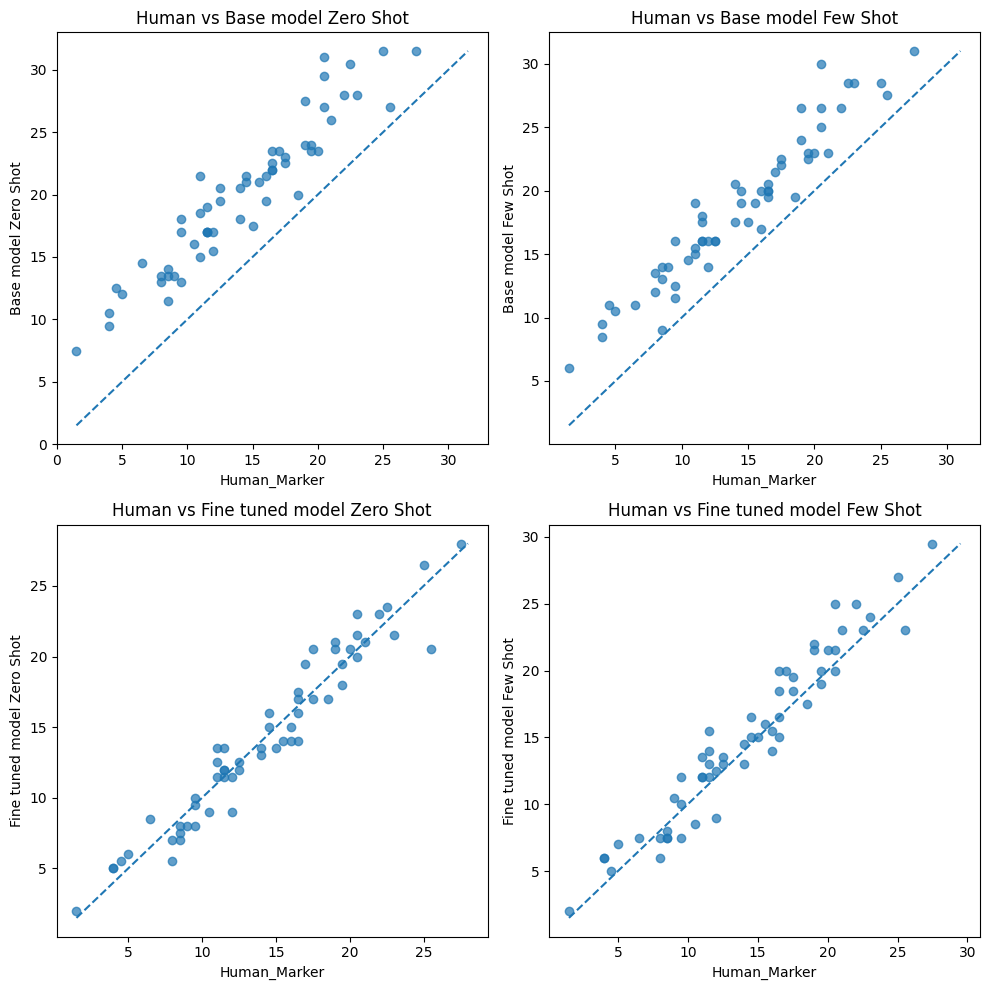

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# flatten 2x2 array of axes into 1D list
axes = axes.flatten()

plot_idx = 0

for col in score_cols:

    if col in unwanted_columns:
        continue

    x = total_scores_df["Human_Marker"]
    y = total_scores_df[col]

    ax = axes[plot_idx]

    ax.scatter(x, y, alpha=0.7)

    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    ax.set_xlabel("Human_Marker")
    ax.set_ylabel(col)
    ax.set_title(f"Human vs {col}")

    plot_idx += 1

plt.tight_layout()
plt.savefig("total_score_plots.png", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
#Helper function for bootstrapping:

def bootstrap_ci(series, n_boot=5000, ci=0.95, random_state=None):
        series = pd.to_numeric(series, errors="coerce").dropna()

        if len(series) == 0:
            return np.nan, np.nan

        results = []

        for i in range(n_boot):
            sample = series.sample(
                n=len(series),
                replace=True,
                random_state=(None if random_state is None else random_state + i)
            )
            results.append(sample.mean())

        alpha = (1 - ci) / 2
        return np.quantile(results, alpha), np.quantile(results, 1 - alpha)

In [ ]:
# Calculate means and 95% CIs for total scores under each condition
score_conditions = [
    'Human_Marker',
    'Base model Zero Shot',
    'Base model Few Shot',
    'Fine tuned model Zero Shot',
    'Fine tuned model Few Shot'
]

results = []

for condition in score_conditions:
    mean = total_scores_df[condition].mean()
    conf_int = bootstrap_ci(total_scores_df[condition])
    conf_low = conf_int[0]
    conf_high = conf_int[1]
    output_dict = [condition, mean, conf_low, conf_high]
    results.append(output_dict)


columns = ["condition", "mean", "CI_low", "CI_high"]
total_score_mean_ci_df = pd.DataFrame(results, columns=columns)
total_score_mean_ci_df    

#Persist means and 95% CIs
total_score_mean_ci_df.to_csv(cwd / "evaluation" / "total_score_mean_ci.csv")

In [55]:
def determine_pass_rate_2(
    total_scores: pd.DataFrame,
    col_names: list,
    target_col: str,
    cut_score=20,
    bootstrap=True,
    n_boot=5000,
    ci=0.95,
    random_state=None,
):
    total_scores = total_scores.copy()

    def bootstrap_agreement_ci(agreement_series, n_boot=5000, ci=0.95, random_state=None):
        agreement_series = agreement_series.dropna()

        categories = ["True_Pass", "False_Fail", "False_Pass", "True_Fail"]

        if len(agreement_series) == 0:
            return {cat: (np.nan, np.nan) for cat in categories}

        boot_results = {cat: [] for cat in categories}

        for i in range(n_boot):
            sample = agreement_series.sample(
                n=len(agreement_series),
                replace=True,
                random_state=(None if random_state is None else random_state + i)
            )

            proportions = sample.value_counts(normalize=True)

            for cat in categories:
                boot_results[cat].append(proportions.get(cat, 0))

        alpha = (1 - ci) / 2

        return {
            cat: (
                np.quantile(boot_results[cat], alpha),
                np.quantile(boot_results[cat], 1 - alpha)
            )
            for cat in categories
        }

    summary_stats = []

    # First create all pass/fail columns
    for col in col_names:
        pass_col = f"{col}_pass"

        total_scores[pass_col] = np.where(
            pd.to_numeric(total_scores[col], errors="coerce") >= cut_score,
            1,
            0
        )

    target_pass_col = f"{target_col}_pass"

    # Then calculate summary stats and agreement columns
    for col in col_names:
        pass_col = f"{col}_pass"

        pass_rate = total_scores[pass_col].mean()

        col_result = {
            "condition": col,
            "cut_score": cut_score,
            "pass_rate": pass_rate,
            "n_pass": total_scores[pass_col].sum(),
            "n_total": total_scores[pass_col].notna().sum(),
        }

        if bootstrap:
            pass_rate_low, pass_rate_high = bootstrap_ci(
                total_scores[pass_col],
                n_boot=n_boot,
                ci=ci,
                random_state=random_state
            )

            col_result["pass_rate_low"] = pass_rate_low
            col_result["pass_rate_high"] = pass_rate_high

        if col != target_col:
            agreement_col = f"{col}_agreement"

            conditions = [
                (total_scores[target_pass_col] == 1) & (total_scores[pass_col] == 1),
                (total_scores[target_pass_col] == 1) & (total_scores[pass_col] == 0),
                (total_scores[target_pass_col] == 0) & (total_scores[pass_col] == 1),
                (total_scores[target_pass_col] == 0) & (total_scores[pass_col] == 0),
            ]

            choices = [
                "True_Pass",
                "False_Fail",
                "False_Pass",
                "True_Fail",
            ]

            total_scores[agreement_col] = np.select(
                conditions,
                choices,
                default="Missing"
            )

            agreement_counts = total_scores[agreement_col].value_counts(dropna=False)
            n_total = col_result["n_total"]

            col_result["true_pass"] = agreement_counts.get("True_Pass", 0)
            col_result["false_fail"] = agreement_counts.get("False_Fail", 0)
            col_result["false_pass"] = agreement_counts.get("False_Pass", 0)
            col_result["true_fail"] = agreement_counts.get("True_Fail", 0)

            col_result["true_pass_rate"] = col_result["true_pass"] / n_total
            col_result["false_fail_rate"] = col_result["false_fail"] / n_total
            col_result["false_pass_rate"] = col_result["false_pass"] / n_total
            col_result["true_fail_rate"] = col_result["true_fail"] / n_total

            if bootstrap:
                agreement_cis = bootstrap_agreement_ci(
                    total_scores[agreement_col],
                    n_boot=n_boot,
                    ci=ci,
                    random_state=random_state
                )

                col_result["true_pass_rate_low"] = agreement_cis["True_Pass"][0]
                col_result["true_pass_rate_high"] = agreement_cis["True_Pass"][1]

                col_result["false_fail_rate_low"] = agreement_cis["False_Fail"][0]
                col_result["false_fail_rate_high"] = agreement_cis["False_Fail"][1]

                col_result["false_pass_rate_low"] = agreement_cis["False_Pass"][0]
                col_result["false_pass_rate_high"] = agreement_cis["False_Pass"][1]

                col_result["true_fail_rate_low"] = agreement_cis["True_Fail"][0]
                col_result["true_fail_rate_high"] = agreement_cis["True_Fail"][1]

        summary_stats.append(col_result)

    summary_results_df = pd.DataFrame(summary_stats)

    return total_scores, summary_results_df

In [56]:
columns_for_pass_rate_calc = ['Human_Marker', 
        'Base model Zero Shot',
       'Base model Few Shot', 
       'Fine tuned model Zero Shot',
       'Fine tuned model Few Shot',
       ]

In [57]:
# call function to calculate pass rates by condition and 95% CIs
total_scores, pass_rates_agreement_df = determine_pass_rate_2(
    total_scores= total_scores_df,
    col_names = columns_for_pass_rate_calc,
    target_col= 'Human_Marker',
    cut_score=20,
    bootstrap=True,
    n_boot=5000,
    ci=0.95,
    random_state=None,
    )

In [58]:
# view pass rates summary data
pass_rates_agreement_df

,condition,cut_score,pass_rate,n_pass,n_total,pass_rate_low,pass_rate_high,true_pass,false_fail,false_pass,...,false_pass_rate,true_fail_rate,true_pass_rate_low,true_pass_rate_high,false_fail_rate_low,false_fail_rate_high,false_pass_rate_low,false_pass_rate_high,true_fail_rate_low,true_fail_rate_high
0,Human_Marker,20,0.189655,11,58,0.103448,0.293103,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Base model Zero Shot,20,0.517241,30,58,0.396552,0.655172,11.0,0.0,19.0,...,0.327586,0.482759,0.086207,0.293103,0.0,0.0,0.206897,0.448276,0.362069,0.603879
2,Base model Few Shot,20,0.413793,24,58,0.293103,0.534483,11.0,0.0,13.0,...,0.224138,0.586207,0.086207,0.293103,0.0,0.0,0.120690,0.344828,0.448276,0.706897
3,Fine tuned model Zero Shot,20,0.241379,14,58,0.137931,0.362069,11.0,0.0,3.0,...,0.051724,0.758621,0.103448,0.293103,0.0,0.0,0.000000,0.120690,0.637931,0.862069
4,Fine tuned model Few Shot,20,0.275862,16,58,0.172414,0.396552,11.0,0.0,5.0,...,0.086207,0.724138,0.086207,0.293103,0.0,0.0,0.017241,0.172414,0.603448,0.827586


In [59]:
# Persist pass rates summary data
pass_rates_agreement_df.to_csv(cwd / "evaluation" / "pass_rates_agreement.csv", index=False)

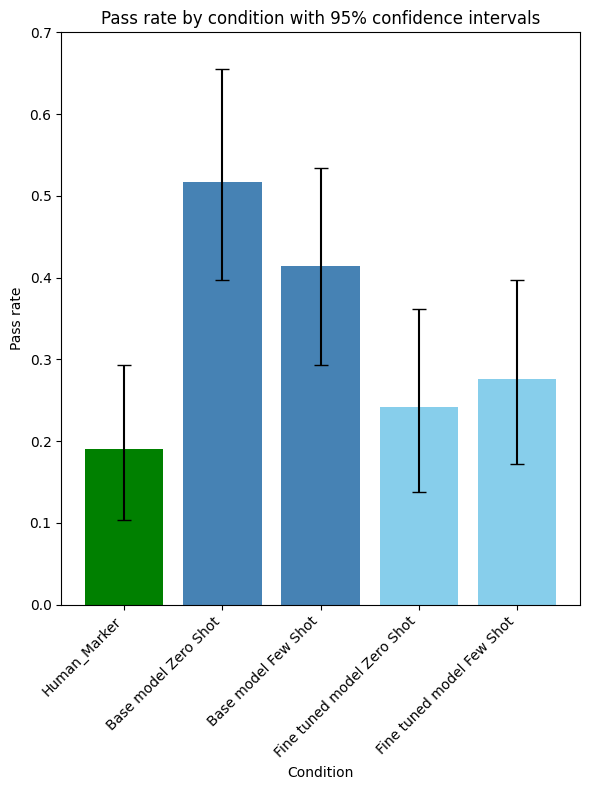

In [60]:
# Plot pass rates by condition
plot_df = pass_rates_agreement_df.copy()

x = np.arange(len(plot_df))

y = plot_df["pass_rate"]
y_lower = plot_df["pass_rate"] - plot_df["pass_rate_low"]
y_upper = plot_df["pass_rate_high"] - plot_df["pass_rate"]

plt.figure(figsize=(6, 8))

colours = ["green", "steelblue","steelblue","skyblue","skyblue"]
plt.bar(
    x,
    y,
    yerr=[y_lower, y_upper],
    capsize=5,
    color=colours
)

plt.xticks(
    x,
    plot_df["condition"],
    rotation=45,
    ha="right"
)

plt.ylabel("Pass rate")
plt.xlabel("Condition")
plt.title("Pass rate by condition with 95% confidence intervals")
plt.ylim(0, 0.7)

plt.tight_layout()
pass_rate_plot_path = cwd / "evaluation" / "pass_rate_plot.png"
plt.savefig(pass_rate_plot_path, dpi=300, bbox_inches="tight")
plt.show()

In [61]:
# view total scores df
total_scores

,Student_ID,Human_Marker,Base model Zero Shot,Base model Few Shot,Fine tuned model Zero Shot,Fine tuned model Few Shot,Zero_Shot_Delta,Few_Shot_Delta,Fine_Tune_ZS_Delta,Fine_Tune_FS_Delta,Human_Marker_pass,Base model Zero Shot_pass,Base model Few Shot_pass,Fine tuned model Zero Shot_pass,Fine tuned model Few Shot_pass,Base model Zero Shot_agreement,Base model Few Shot_agreement,Fine tuned model Zero Shot_agreement,Fine tuned model Few Shot_agreement
0,1018518,14.5,21.0,20.0,15.0,15.0,6.5,5.5,0.5,0.5,0,1,1,0,0,False_Pass,False_Pass,True_Fail,True_Fail
1,1128260,22.0,28.0,26.5,23.0,25.0,6.0,4.5,1.0,3.0,1,1,1,1,1,True_Pass,True_Pass,True_Pass,True_Pass
2,1128828,11.5,19.0,18.0,12.0,13.0,7.5,6.5,0.5,1.5,0,0,0,0,0,True_Fail,True_Fail,True_Fail,True_Fail
3,1140638,19.5,24.0,22.5,18.0,19.0,4.5,3.0,-1.5,-0.5,0,1,1,0,0,False_Pass,False_Pass,True_Fail,True_Fail
4,1149441,15.5,21.0,19.0,14.0,16.0,5.5,3.5,-1.5,0.5,0,1,0,0,0,False_Pass,True_Fail,True_Fail,True_Fail
5,1154492,20.5,27.0,25.0,20.0,20.0,6.5,4.5,-0.5,-0.5,1,1,1,1,1,True_Pass,True_Pass,True_Pass,True_Pass
6,1212645,15.0,17.5,17.5,13.5,15.0,2.5,2.5,-1.5,0.0,0,0,0,0,0,True_Fail,True_Fail,True_Fail,True_Fail
7,1257430,20.0,23.5,23.0,20.5,21.5,3.5,3.0,0.5,1.5,1,1,1,1,1,True_Pass,True_Pass,True_Pass,True_Pass
8,1276325,11.0,15.0,15.0,11.5,12.0,4.0,4.0,0.5,1.0,0,0,0,0,0,True_Fail,True_Fail,True_Fail,True_Fail
9,1316791,6.5,14.5,11.0,8.5,7.5,8.0,4.5,2.0,1.0,0,0,0,0,0,True_Fail,True_Fail,True_Fail,True_Fail


In [62]:
# persist total score and pass/fail by condition
total_scores.to_csv(cwd / "evaluation" / "total_scores_pass_fail_by_condition.csv")

In [63]:
# Exploring outputs question by question:
def question_subplots(df, questions, model_name):
    question_col = "Question_ID"
    # determine subplot layout
    n_questions = len(questions)
    n_cols = 4
    n_rows = math.ceil(n_questions / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )

    # flatten axes so indexing always works
    axes = axes.flatten()

    for plot_idx, question in enumerate(questions):

        ax = axes[plot_idx]

        specific_question_df = df[df[question_col] == question].copy()

        x = specific_question_df["Human_Marker_Score"]
        y = specific_question_df["Model_score"]

        ax.scatter(x, y, alpha=0.7)

        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())

        # identity line
        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--"
        )

        ax.set_xlabel("Human marker score")
        ax.set_ylabel("Model score")
        ax.set_title(f"Question {question}")

    # remove unused subplot axes
    for i in range(plot_idx + 1, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(
        f"Human vs Model Scores: {model_name}",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    output_name = f"{model_name}_question_comparison_subplots.png"

    plt.savefig(
        cwd / "evaluation" / output_name,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

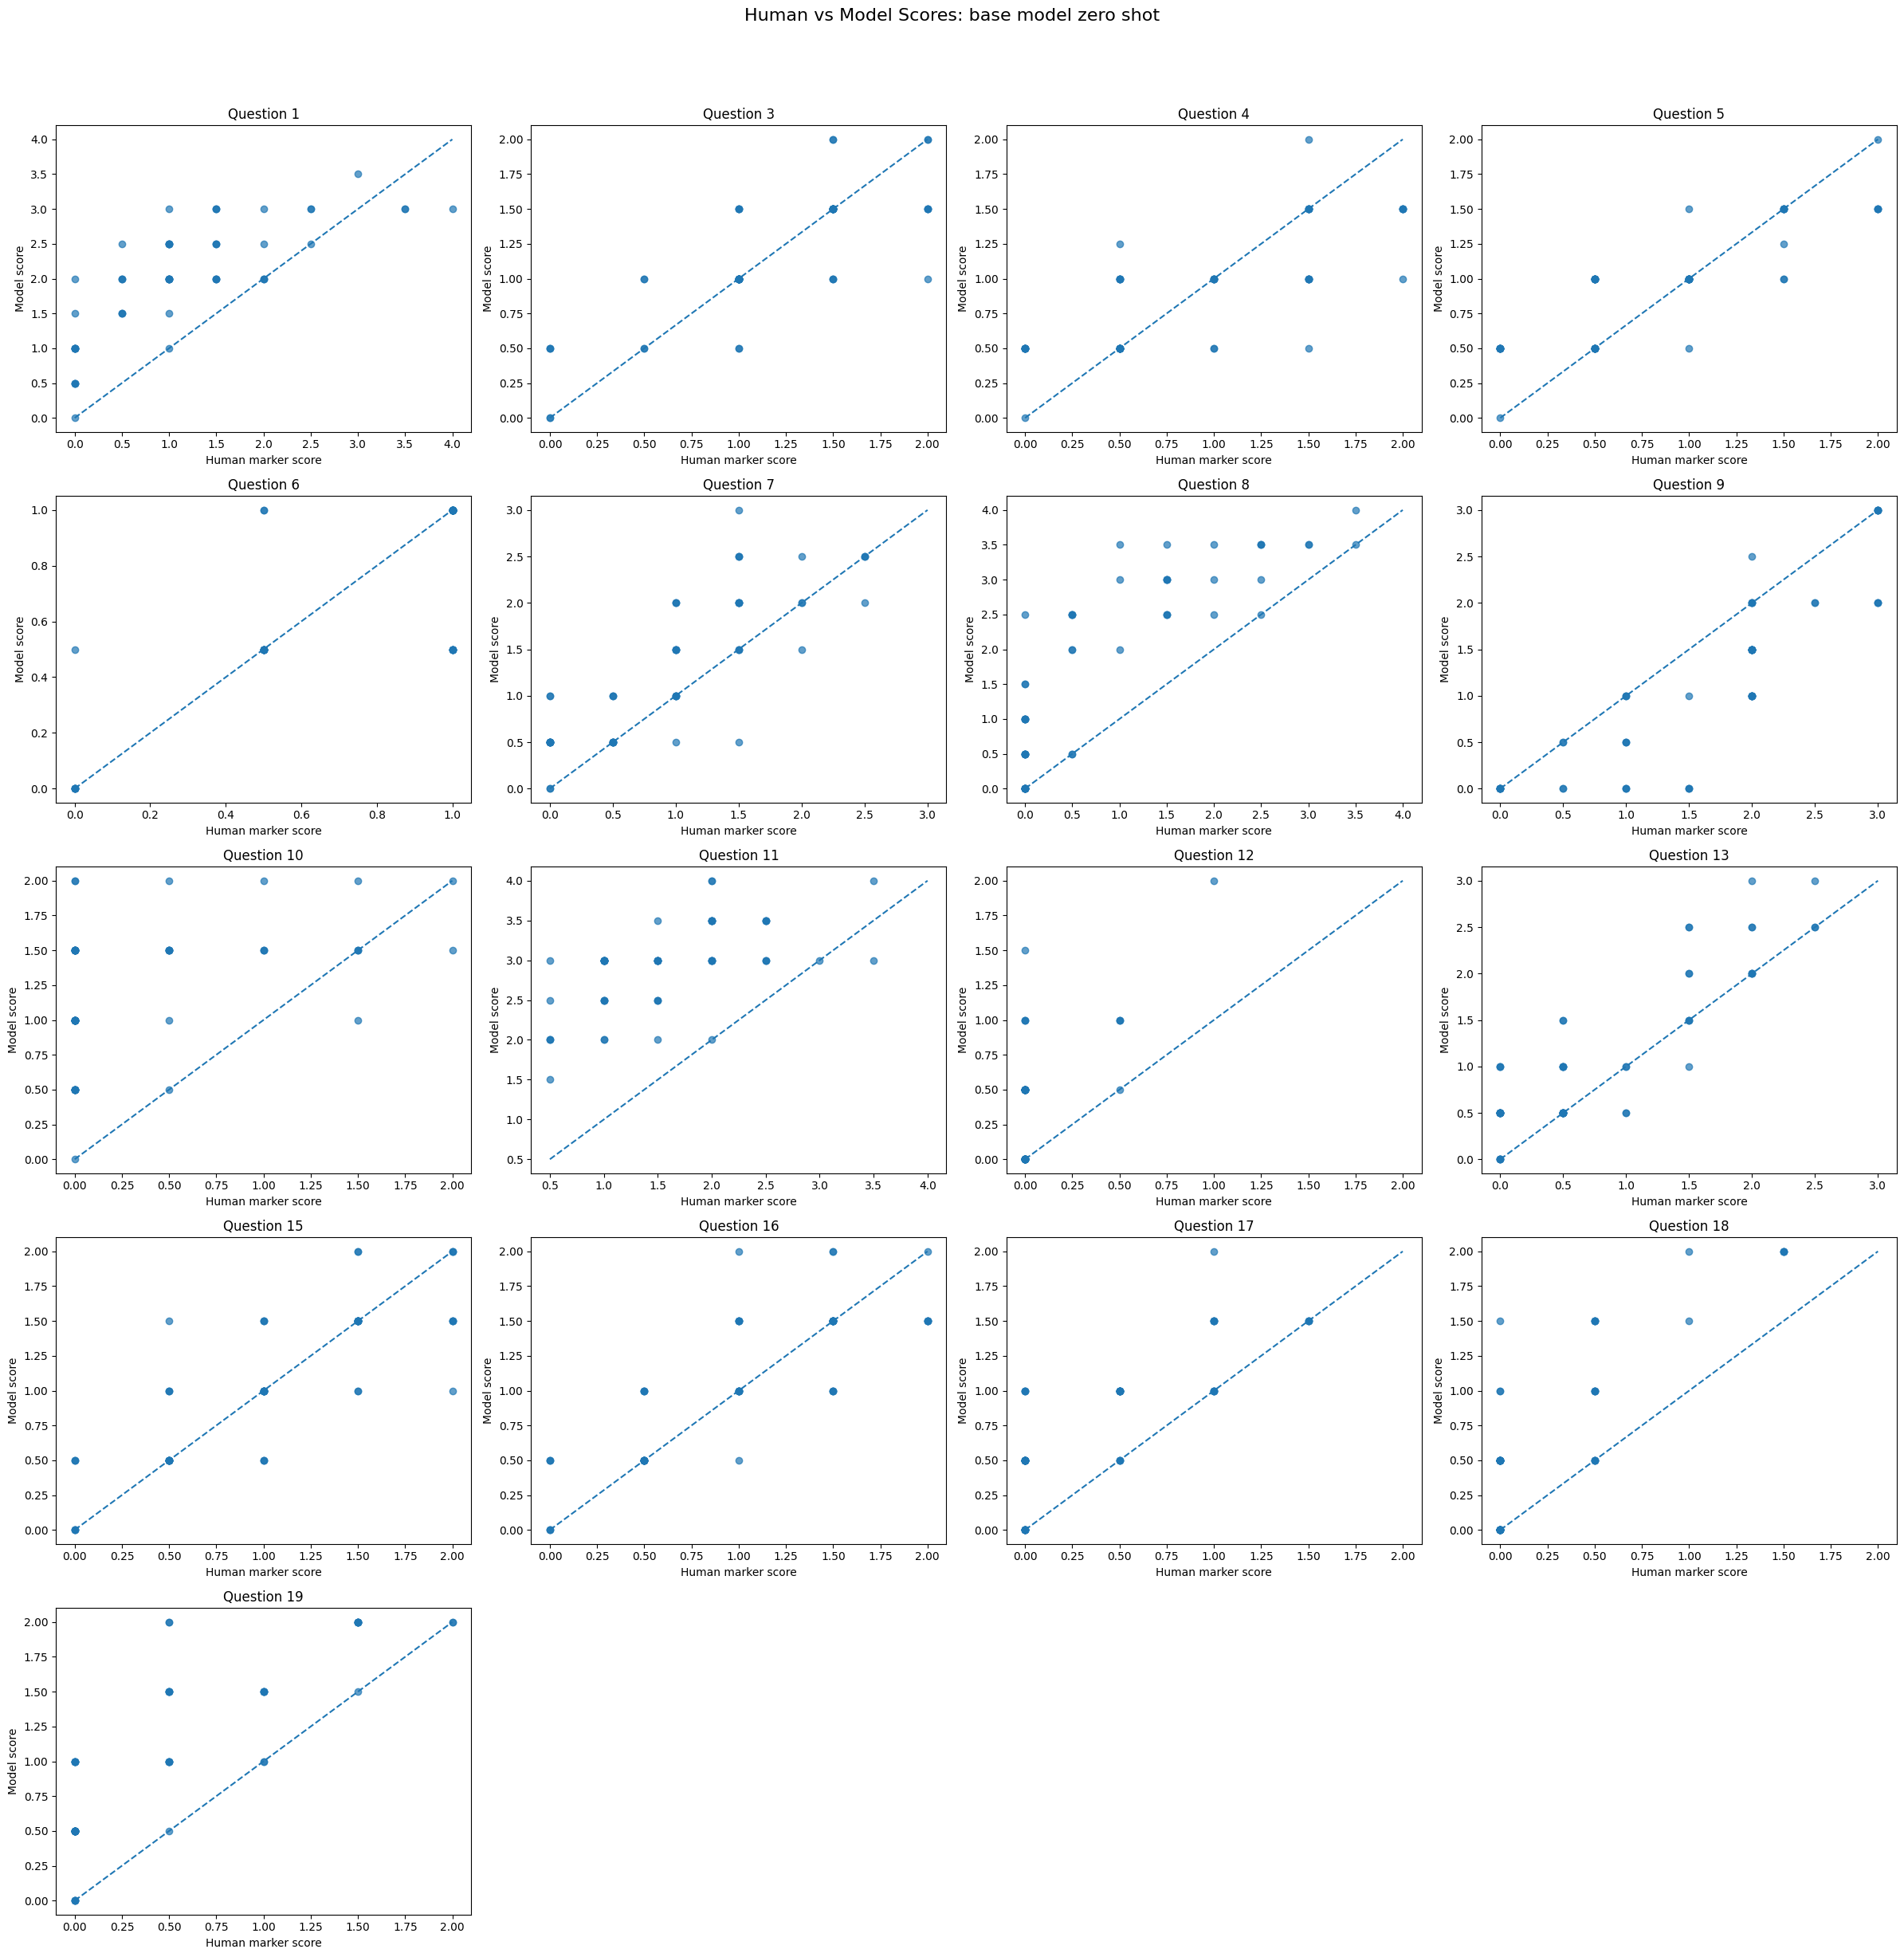

In [64]:
questions = [1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 15, 16, 17, 18, 19]
model_name = "base model zero shot"
df = pd.read_csv(cwd / "model_outputs" / "testing_zero_shot_base_v2.csv")
question_subplots(df, questions, model_name)

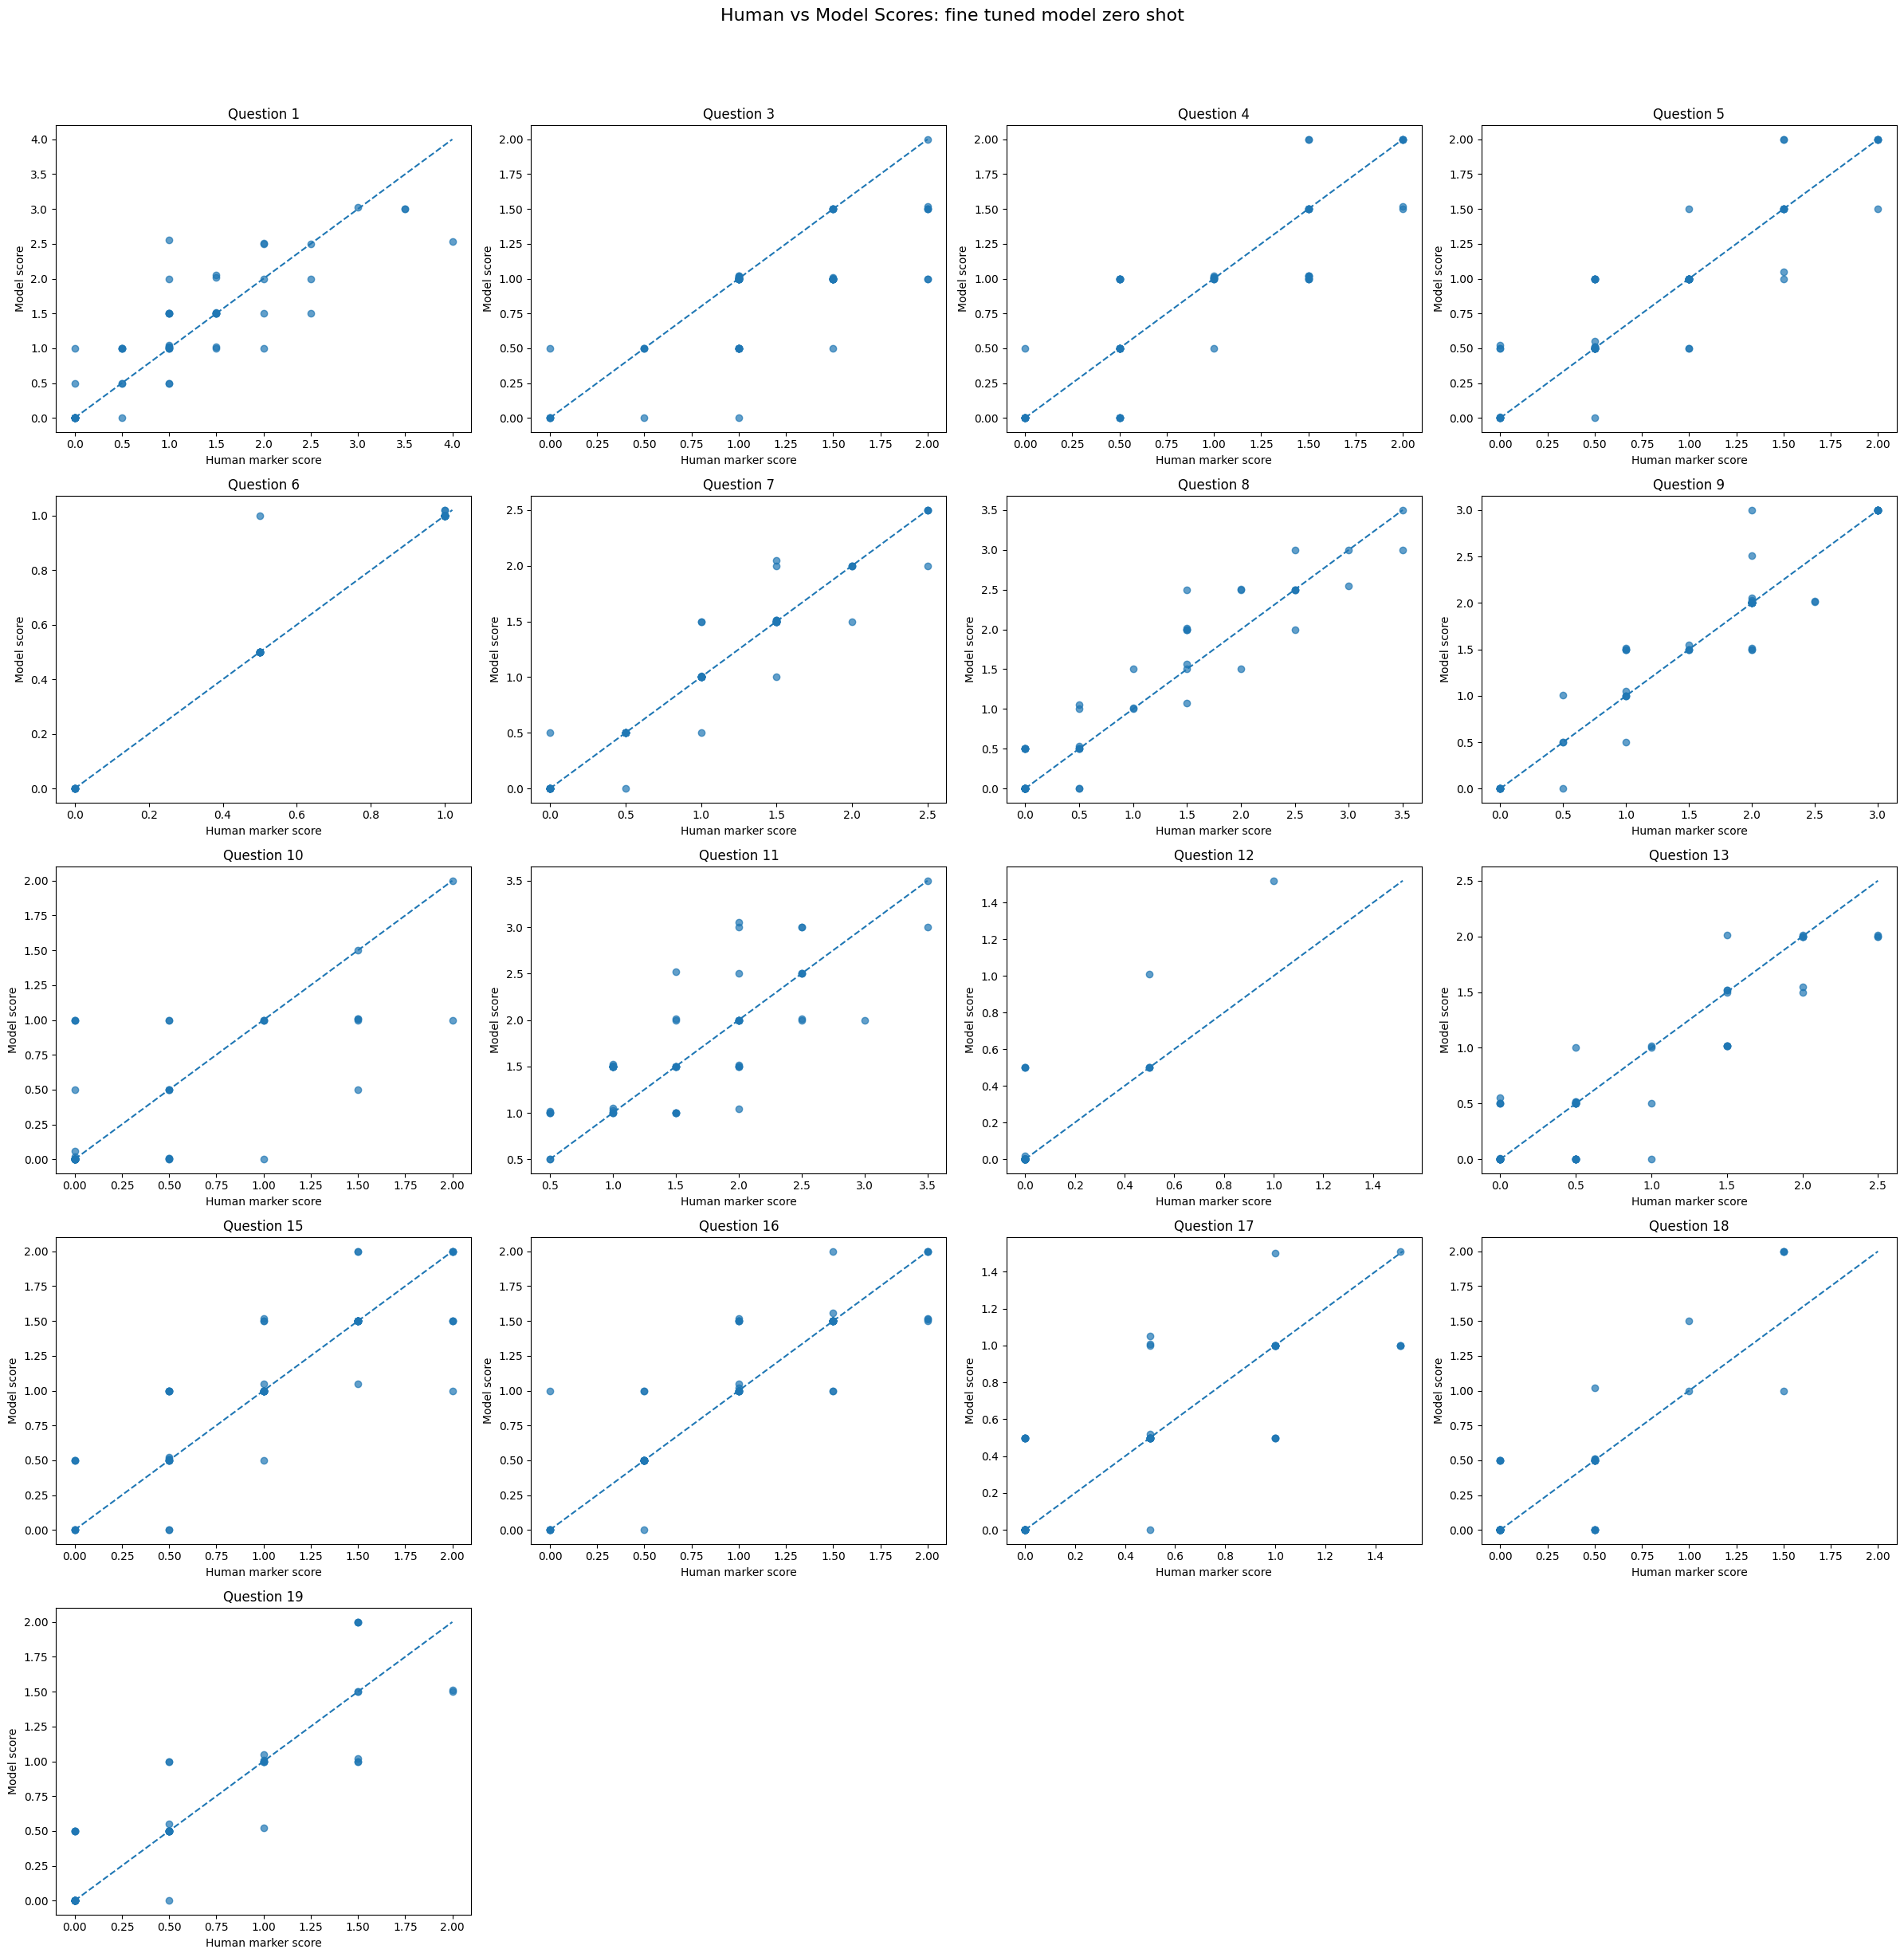

In [65]:
questions = [1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 15, 16, 17, 18, 19]
model_name = "fine tuned model zero shot"
df = pd.read_csv(cwd / "model_outputs" / "testing_zero_shot_FTscores_zs_v1.csv")
question_subplots(df, questions, model_name)